# Topic: Analyzing the Dark Matter Halo Shape of M33 

### Question: How does the ellipticity of M33's DM halo shape change over time in a face-on projection

### Output Plots: Ellipticity versus time of M33's halo taken at R500, R500/2, and R500/4, DM particle density projections 

### Code outline:

1. Loop over every 10 snapshots over full snapshot range
2. Record time, ellipticity, position angle, semimajor axis, and semiminor axis information at the R500, R500/2, and R500/4 distances
3. Save to a table as a row and save full table to txt file
4. Read in txt file to plot ellipticity versus time at each of these distances

In [1]:
# Nicolas Mazziotti

# import modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# import plotting modules
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm

# my modules
from ReadFile import Read
from CenterOfMass import CenterOfMass
from MassProfile import MassProfile
from HaloShape import HaloShape

# for ellipse fitting 
from photutils.isophote import Ellipse, EllipseGeometry

In [2]:
# Directory on nimoy where the high resolution data files are stored
HighResDir = '../../../../astr400b/HighRes/'

# Create Projections At Every 10 Snapshots

In [3]:
# No lists; use arrays, or list comprehension

In [4]:
# Define snapshot range from 0 to 799, using every 10 snaps
snap_range = np.arange(0, 799, 10)

/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 64%|███████████████████████████▍               | 51/80 [07:59<04:32,  9.40

OverflowError: cannot convert float infinity to integer

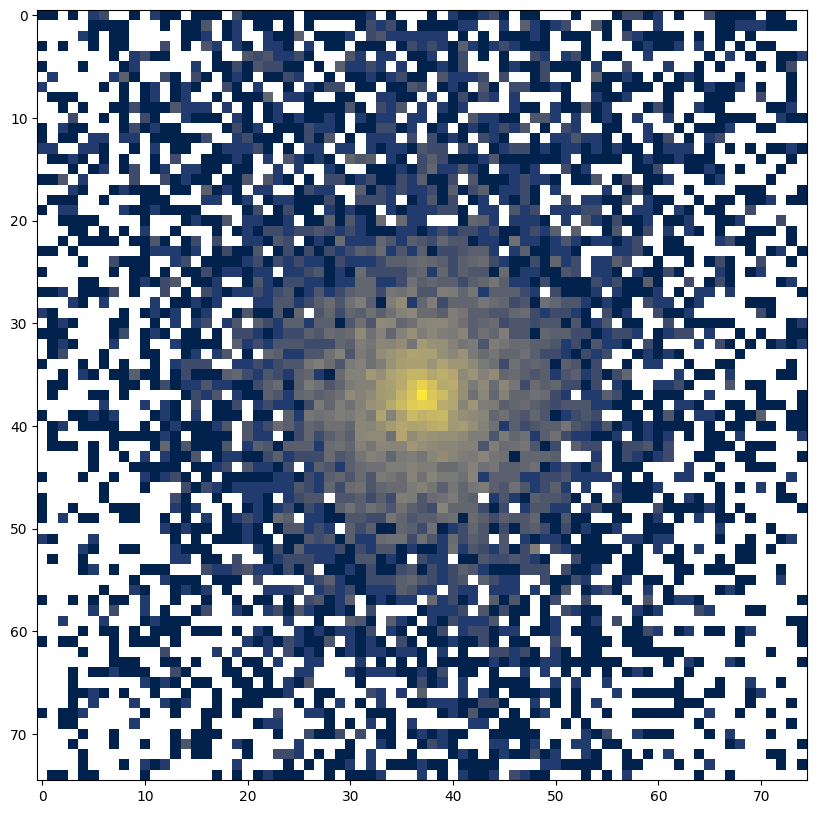

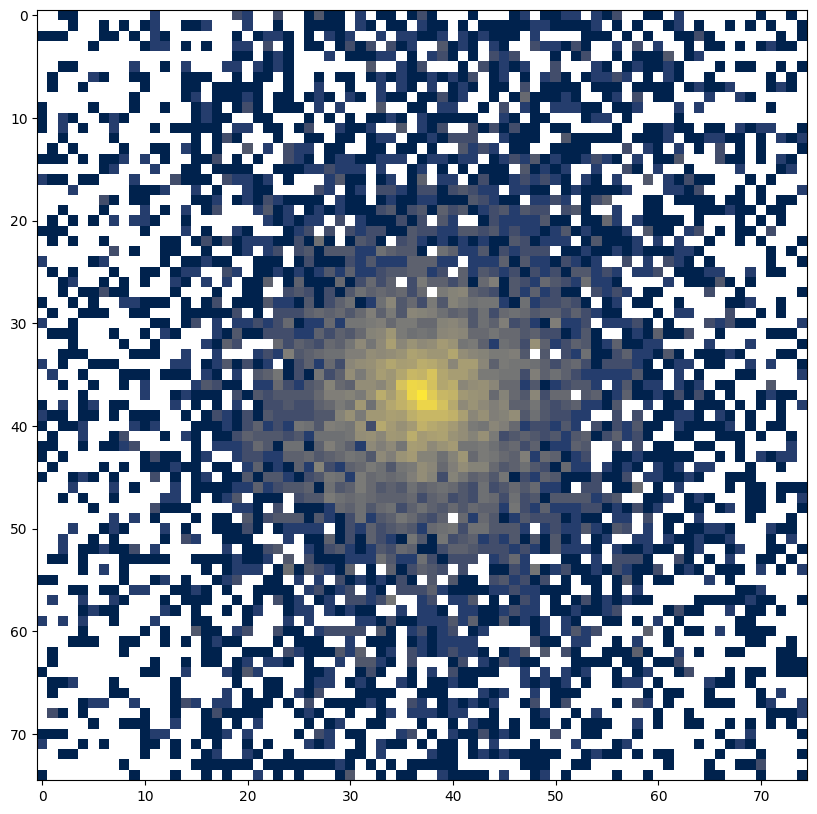

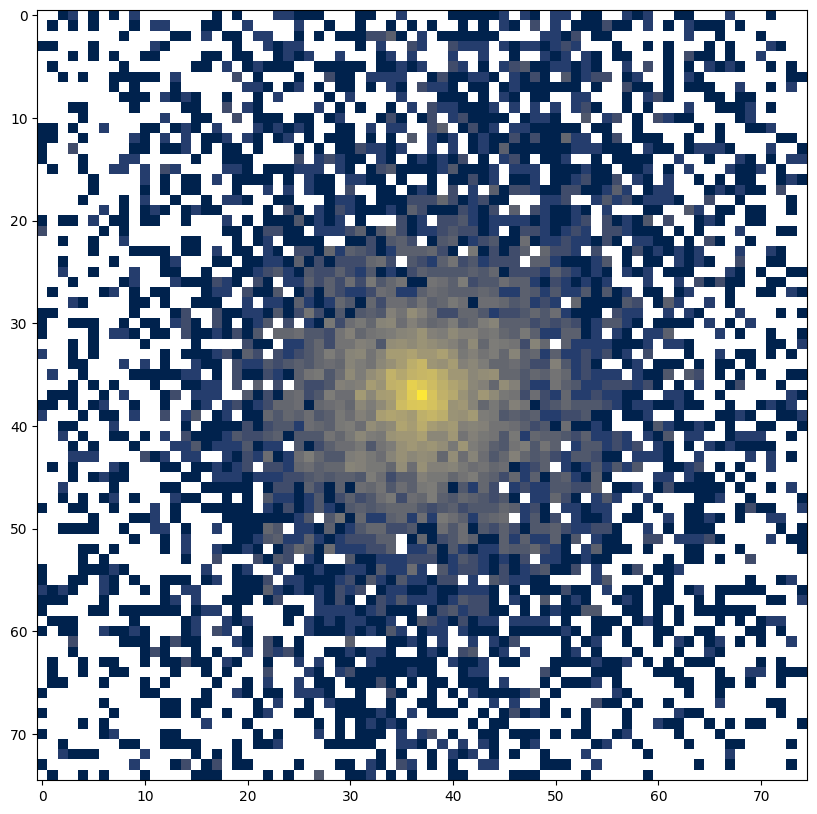

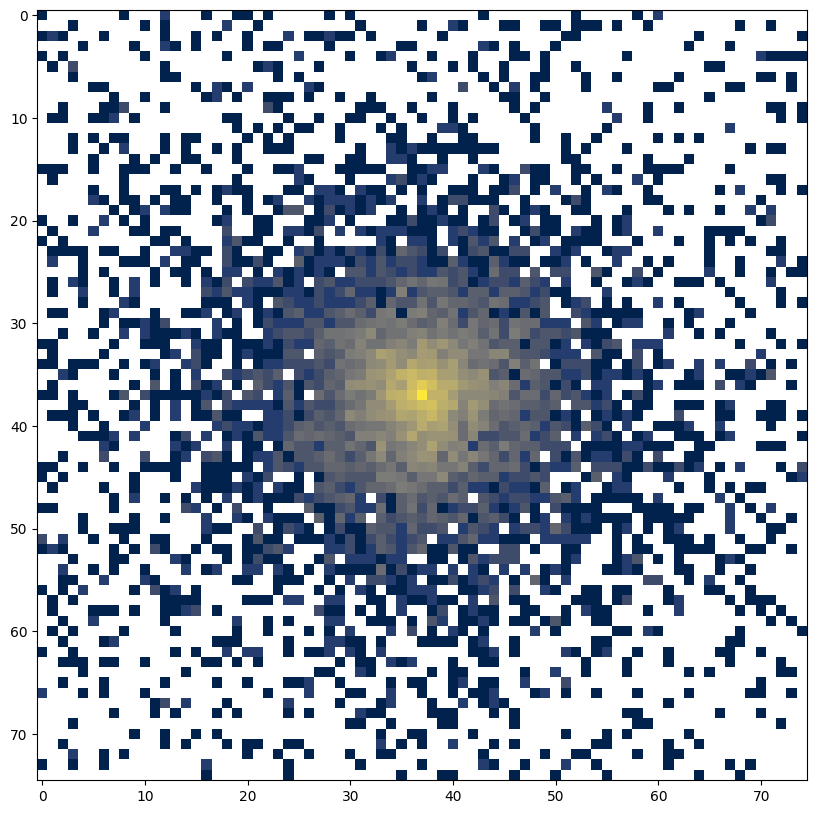

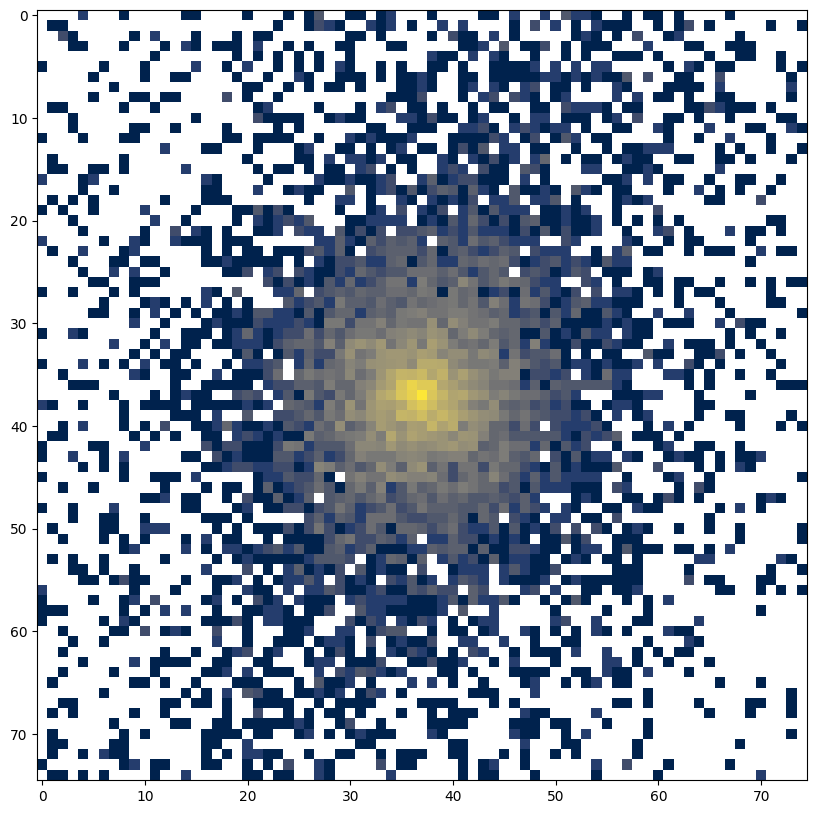

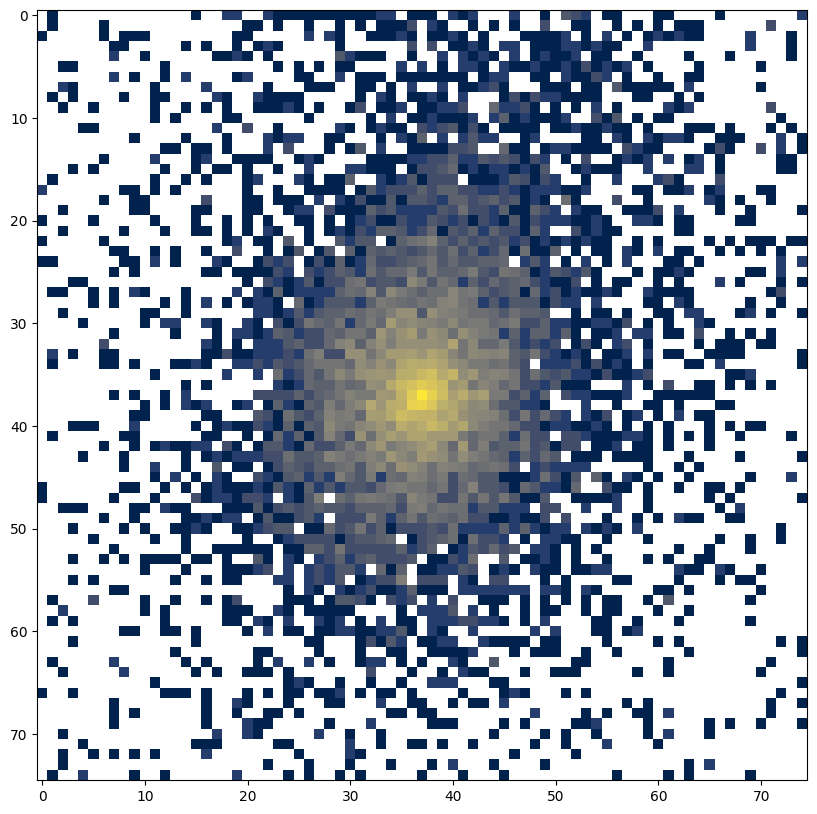

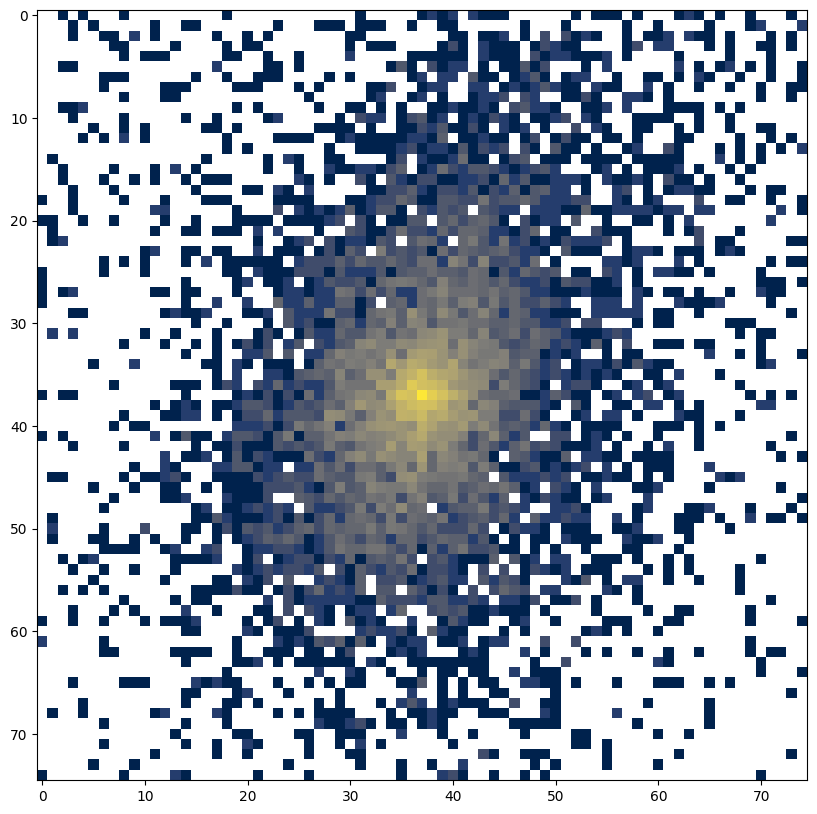

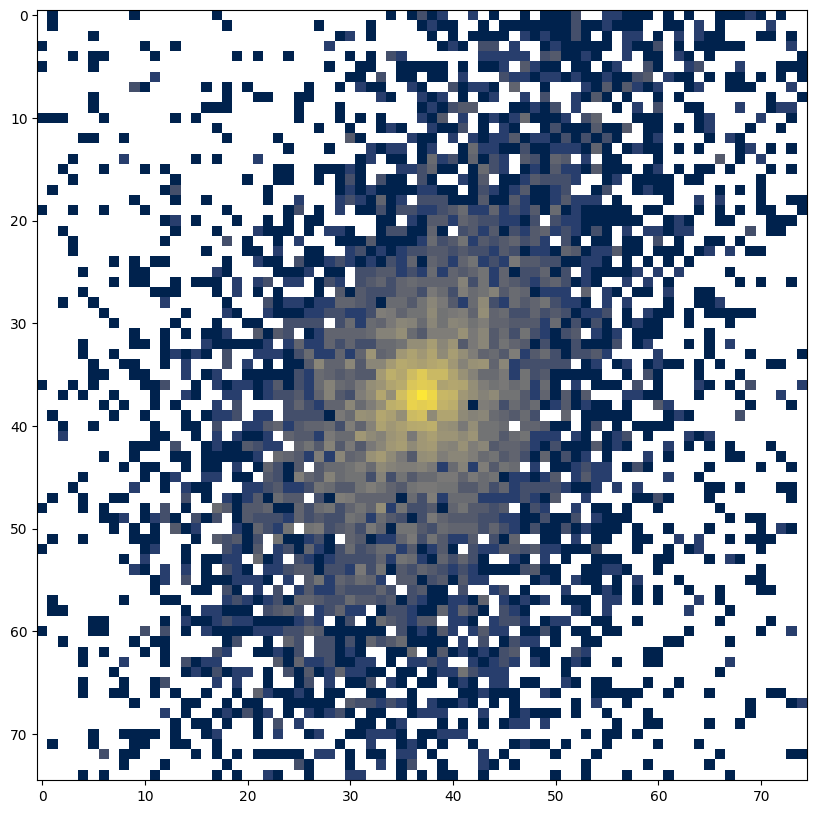

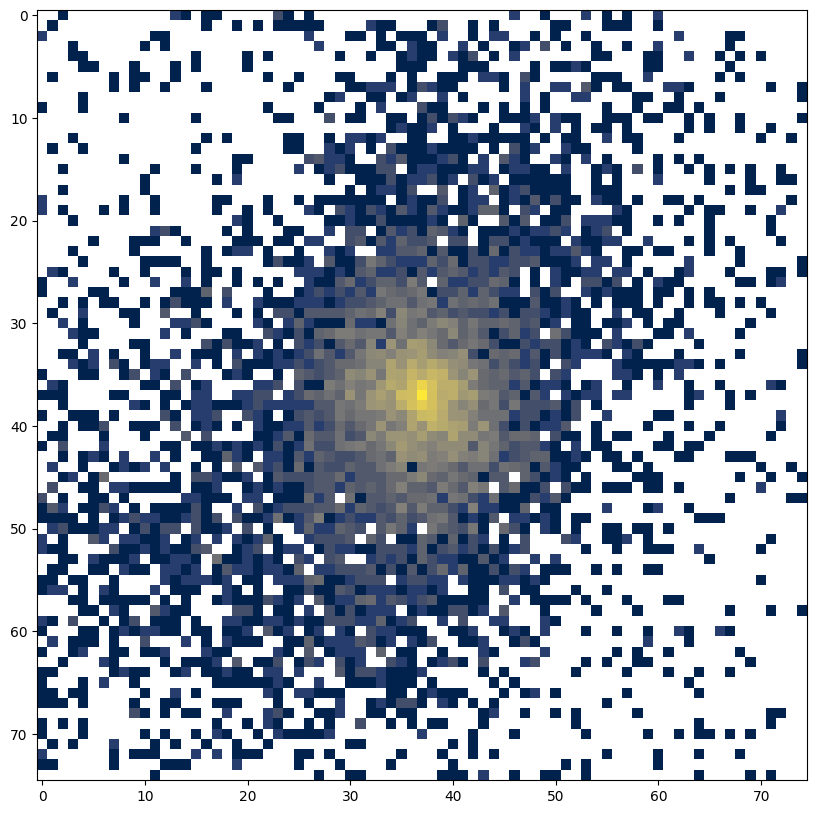

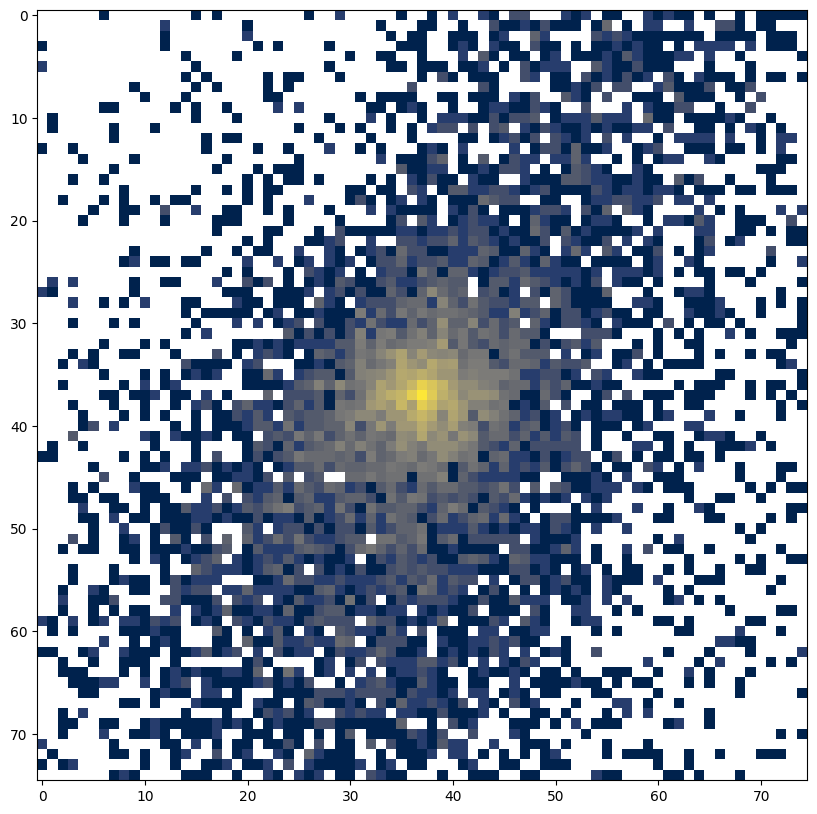

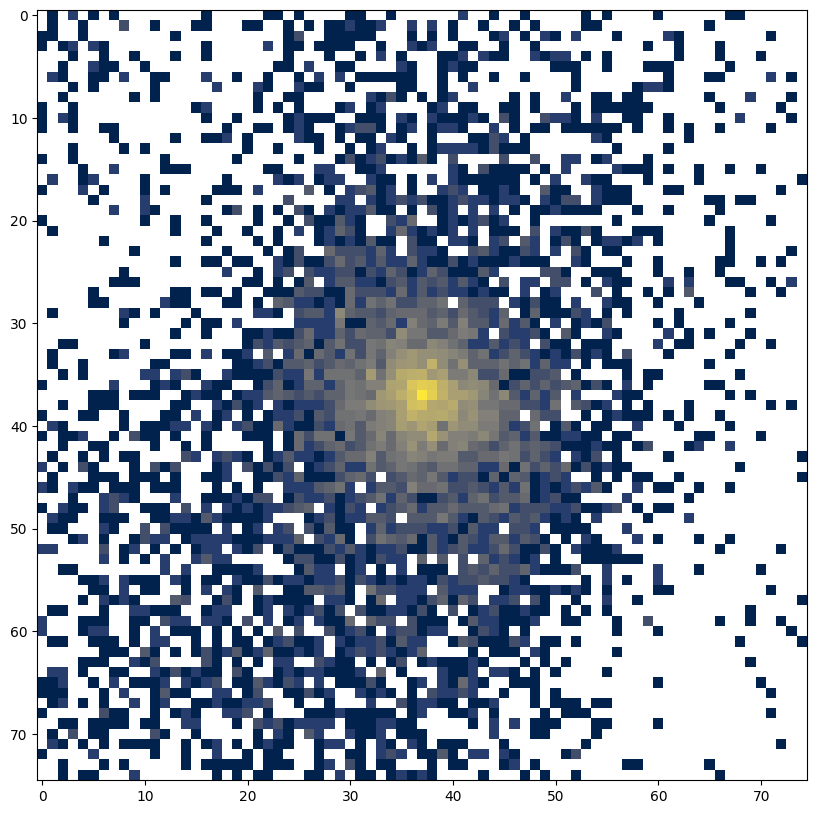

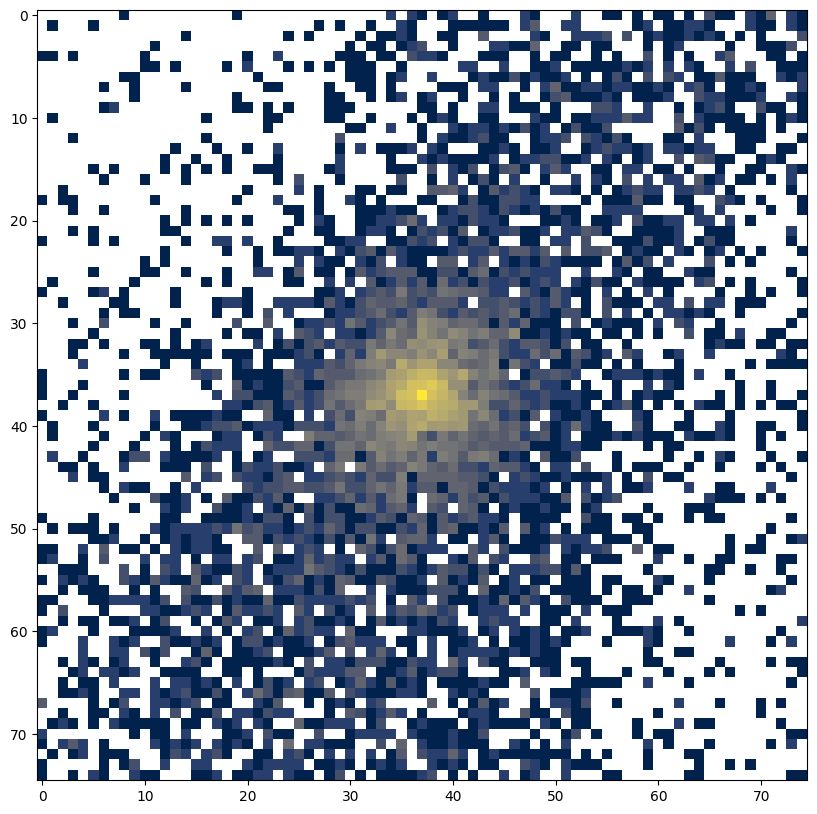

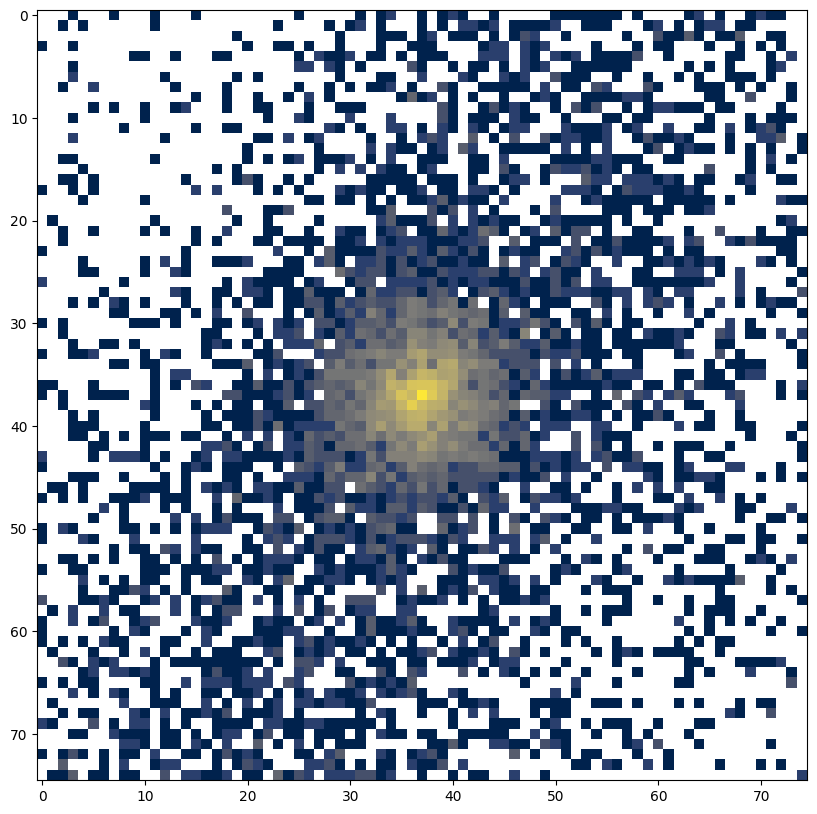

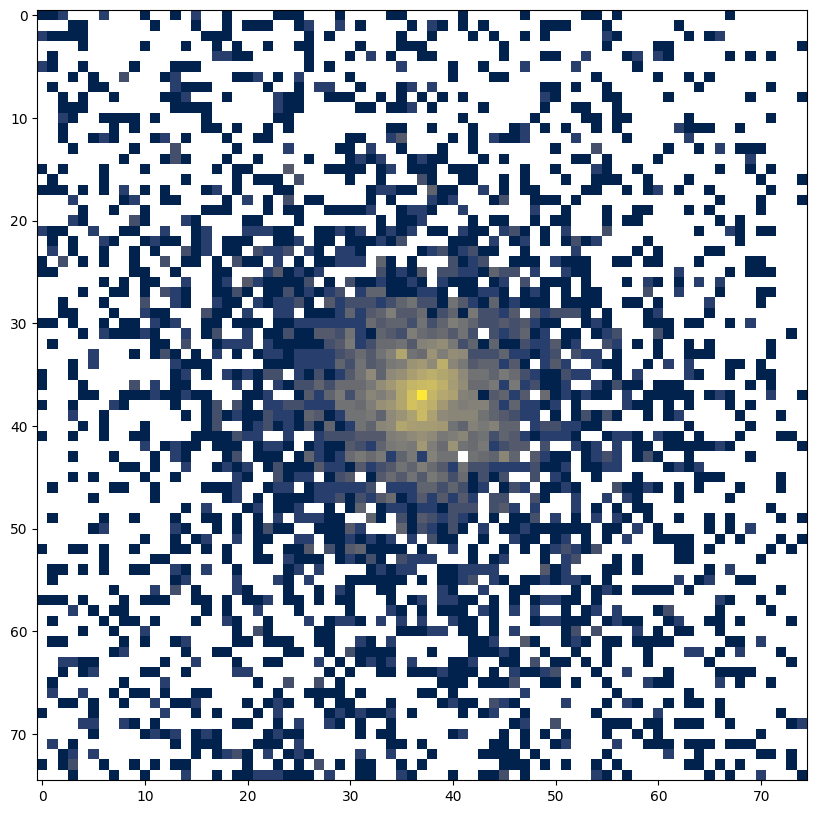

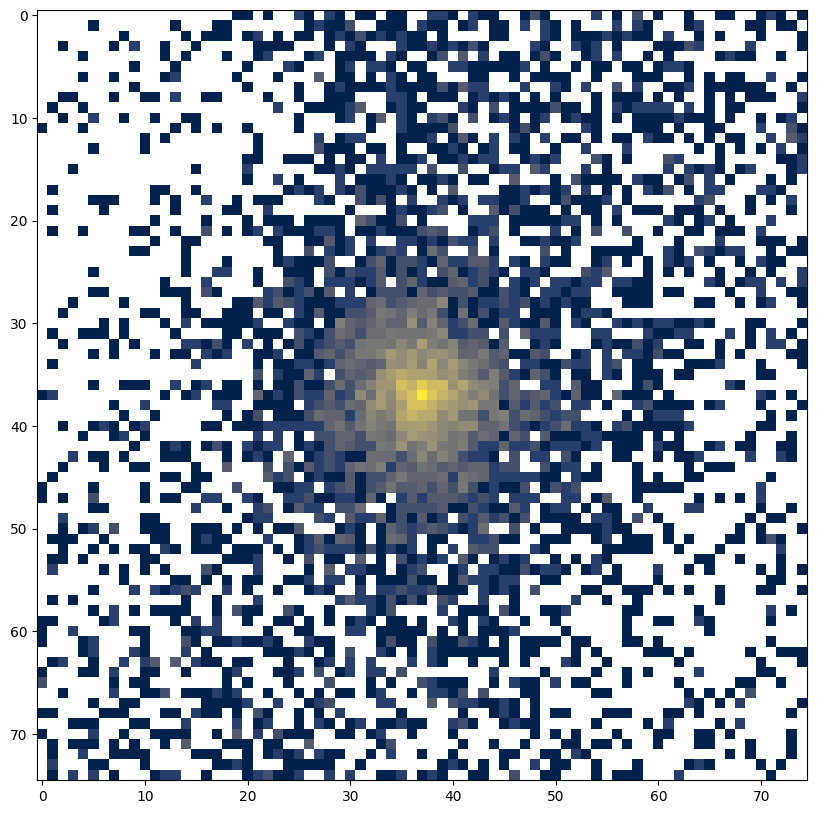

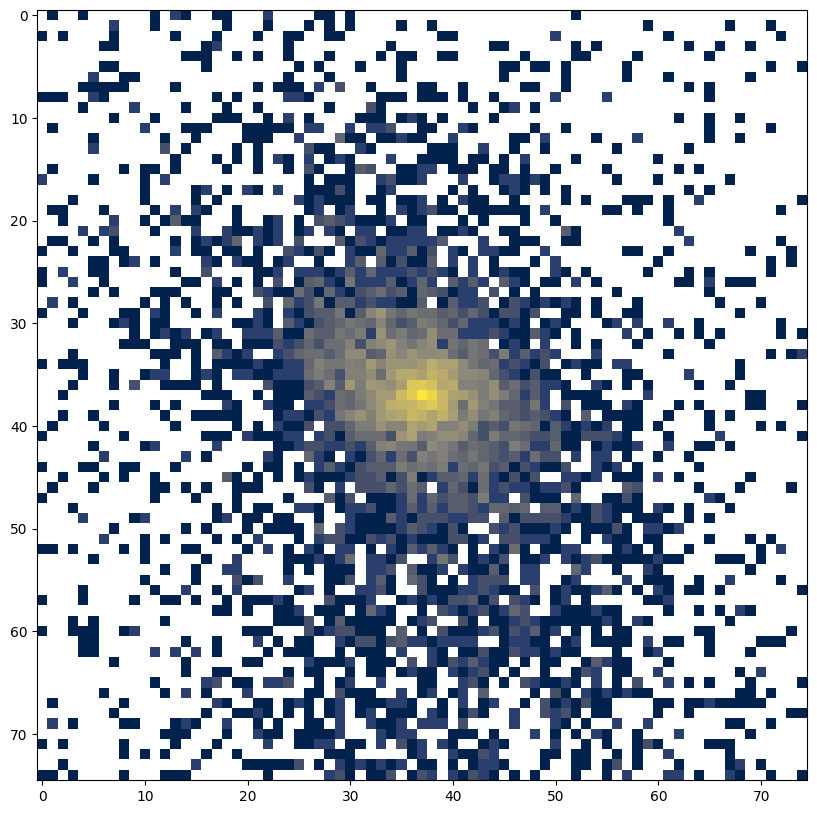

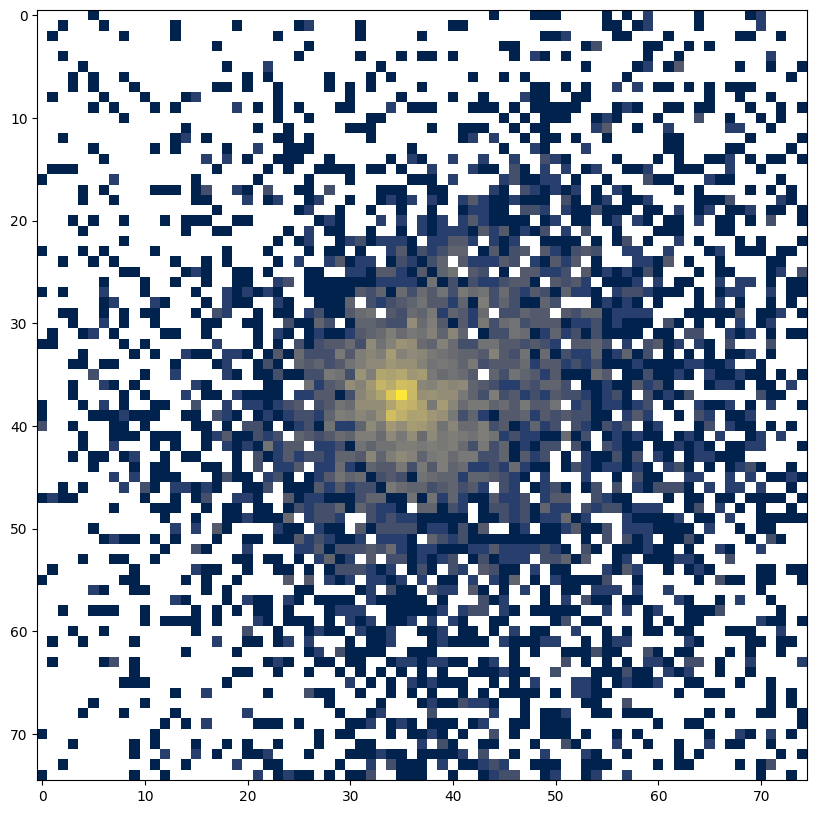

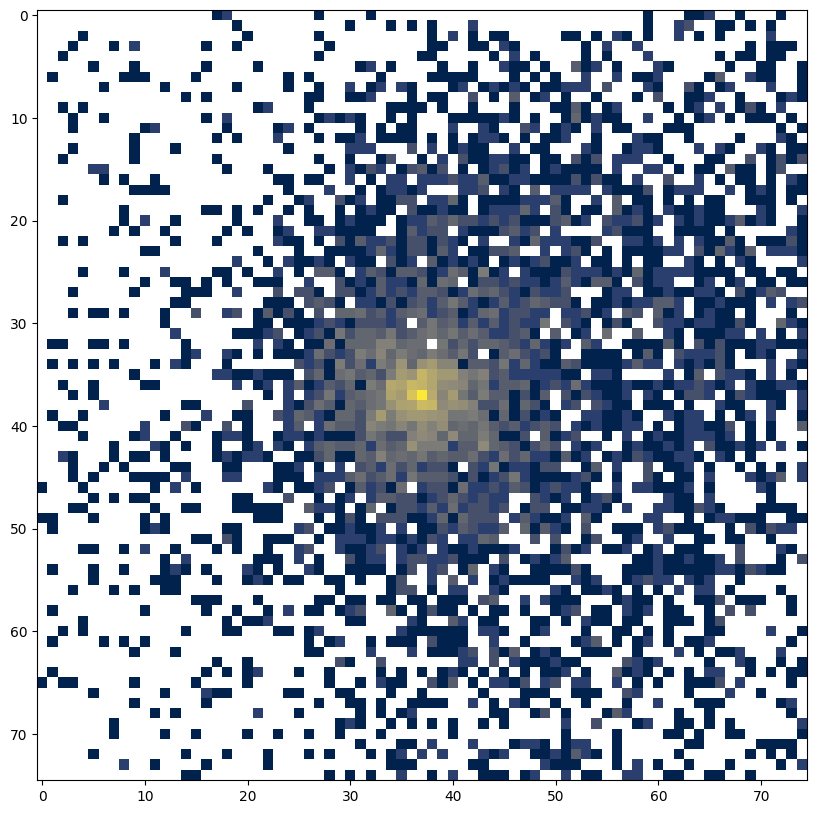

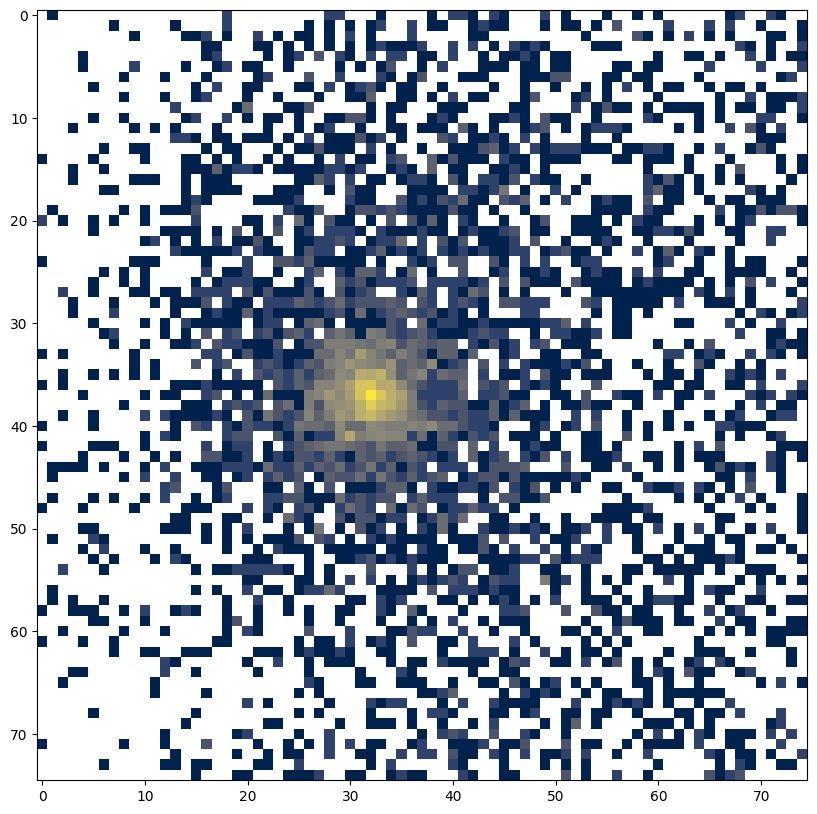

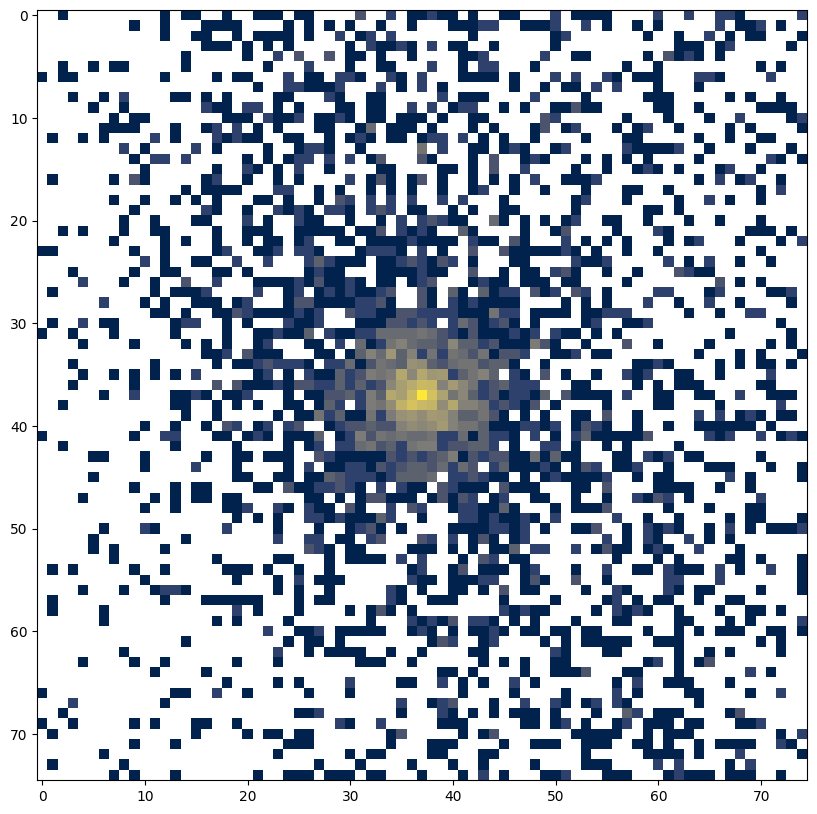

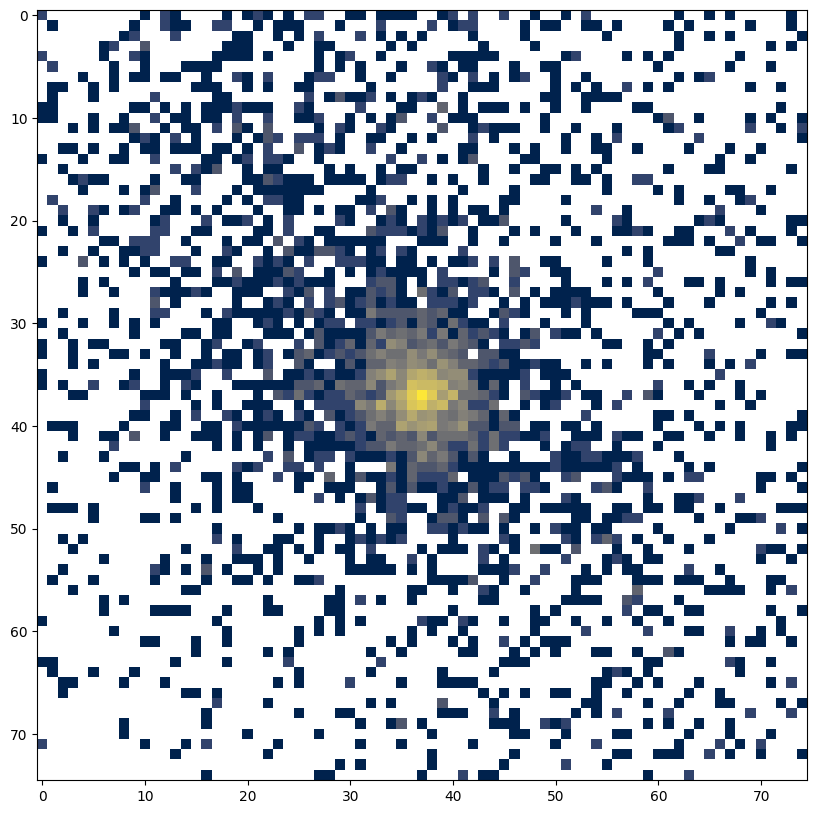

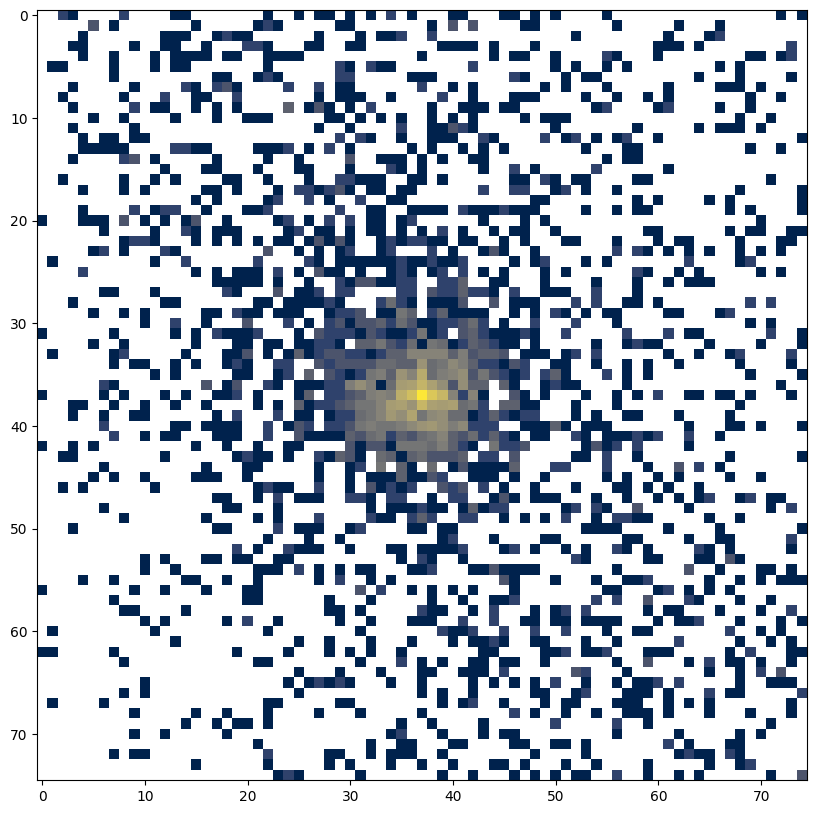

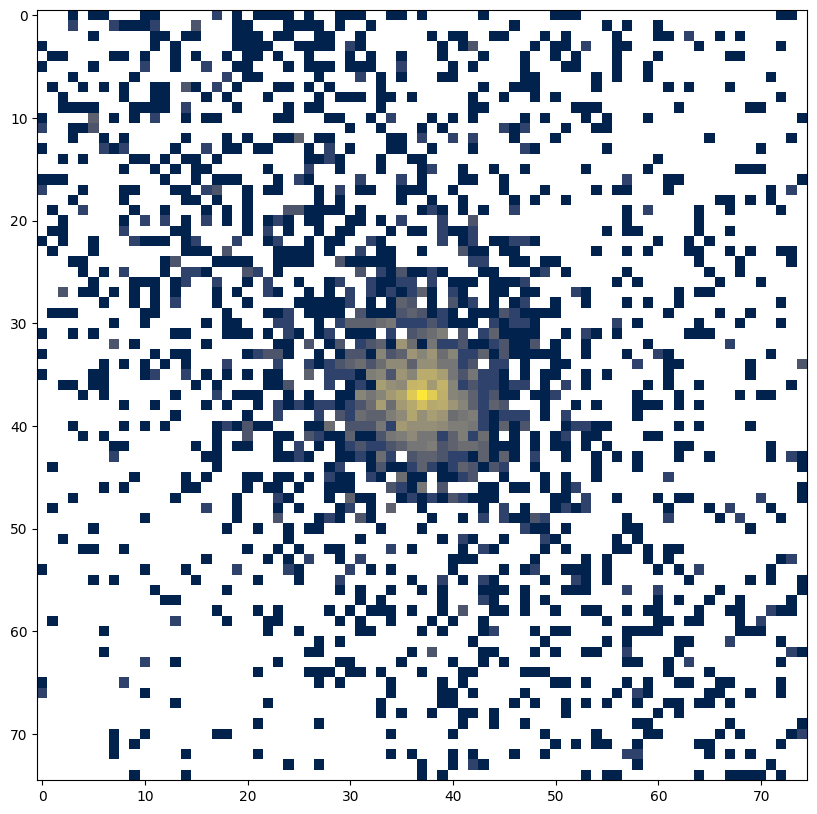

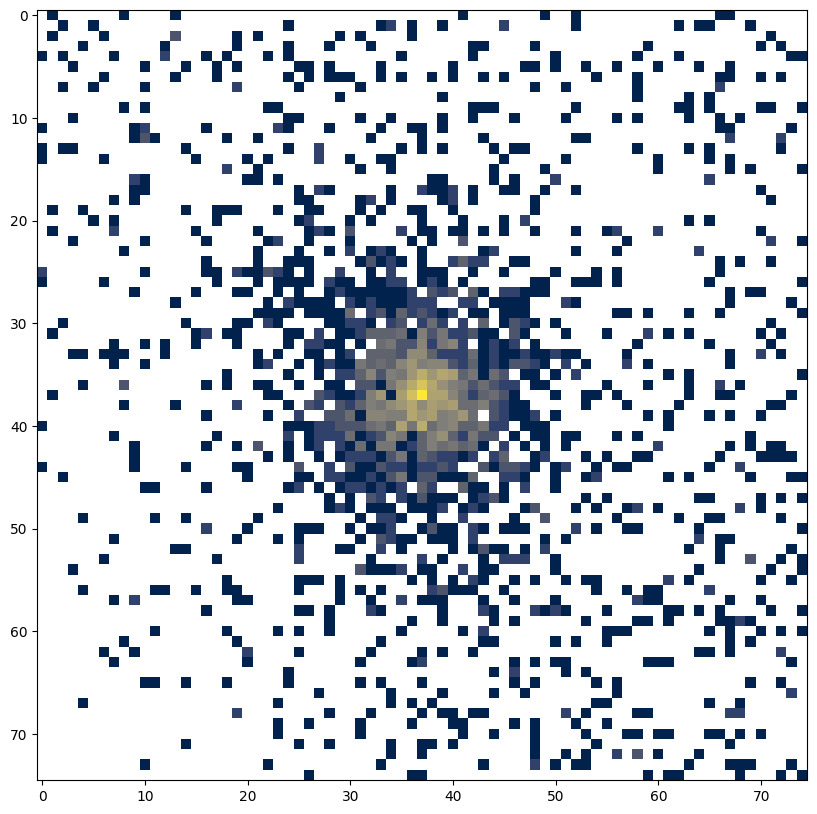

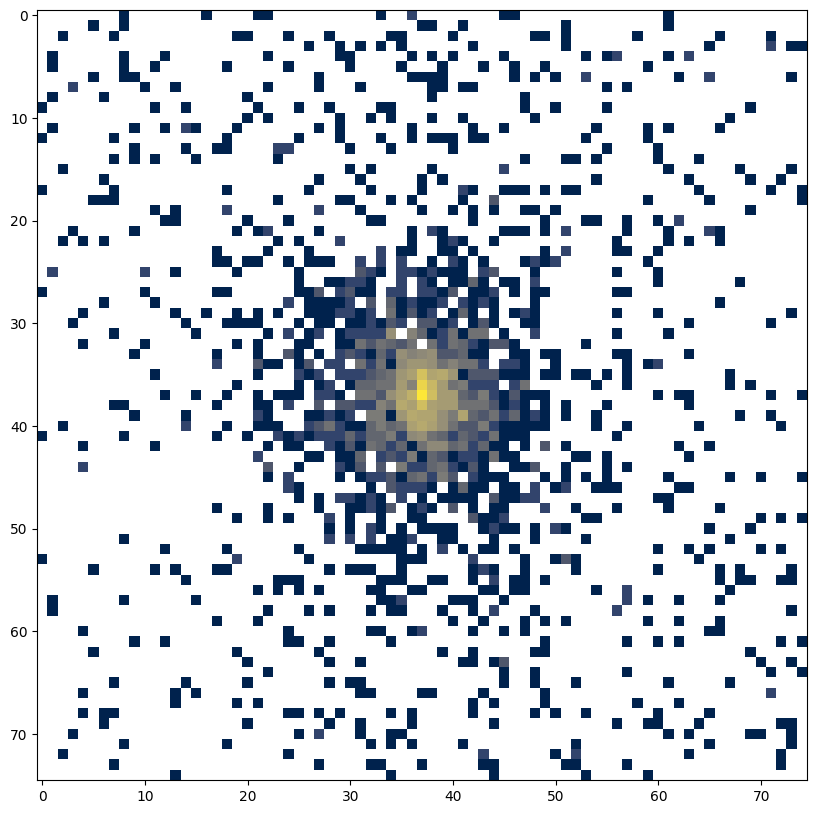

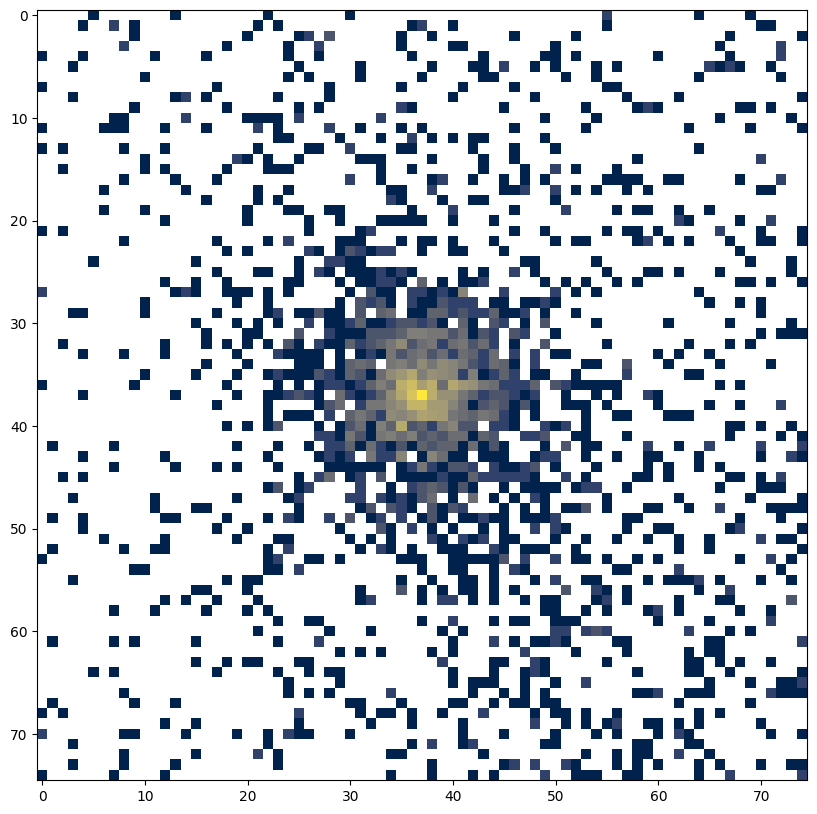

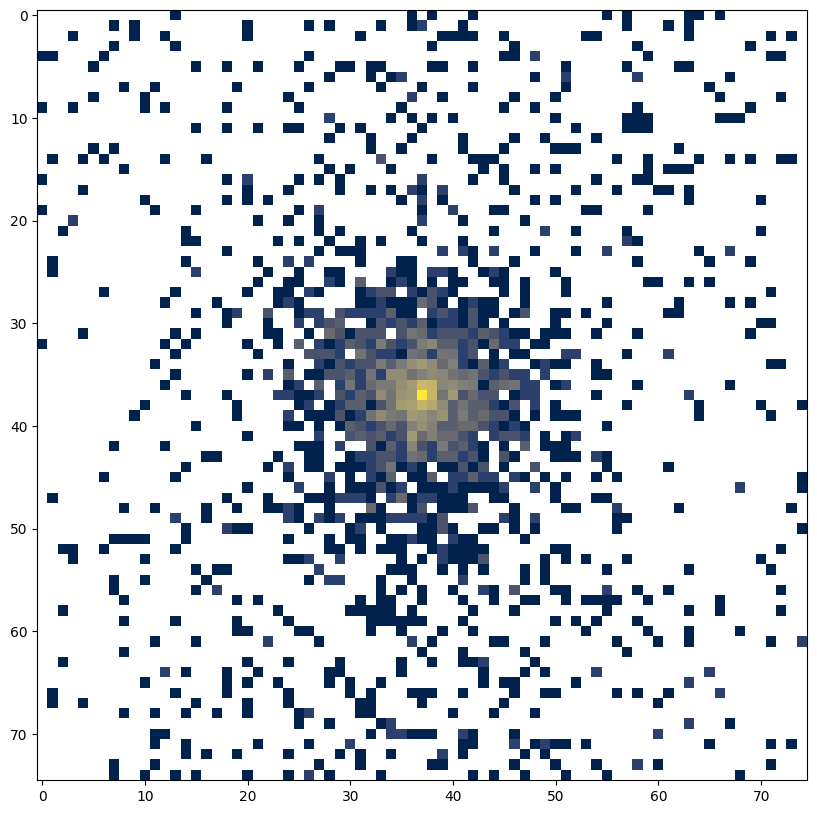

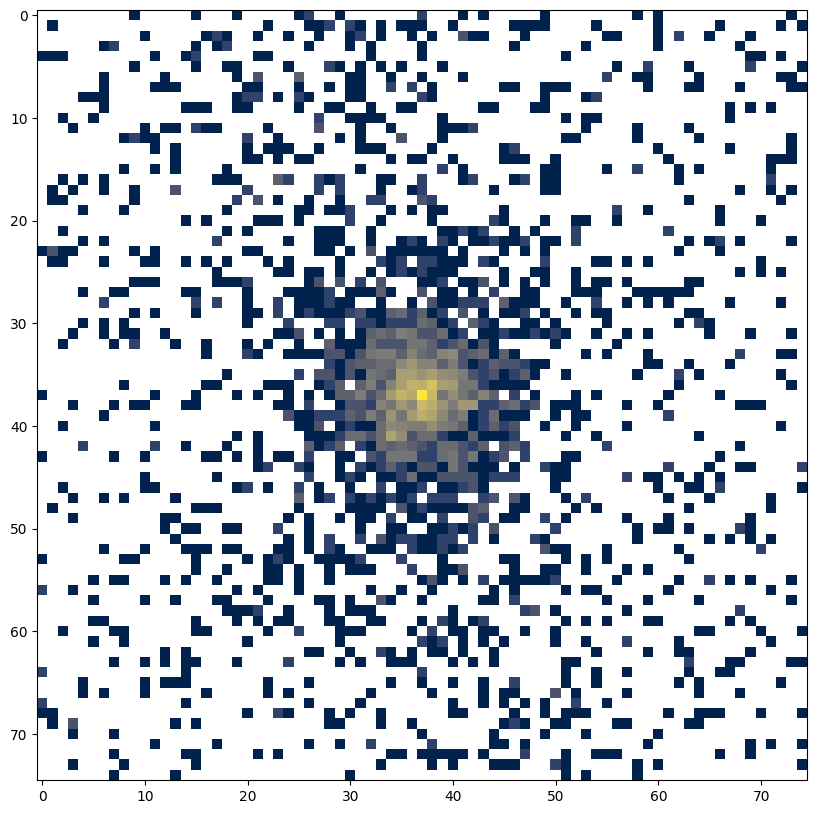

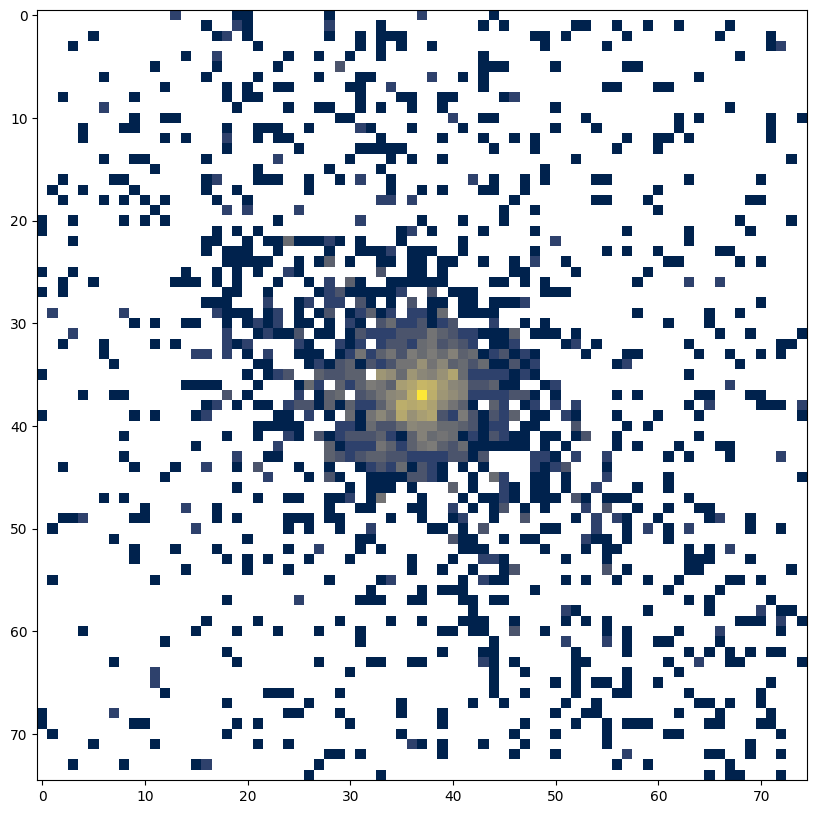

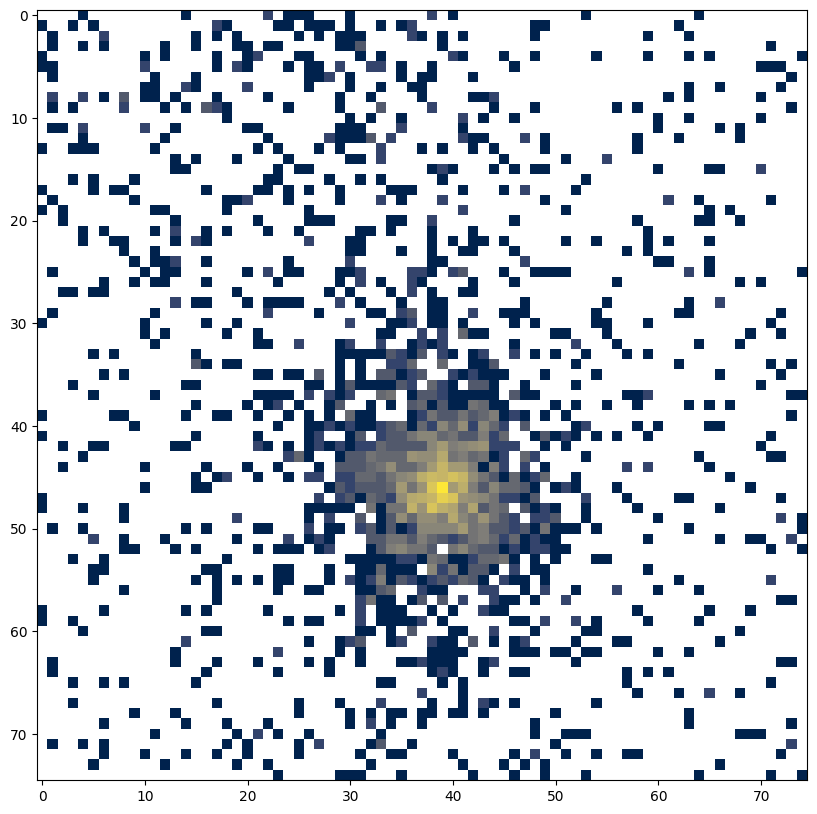

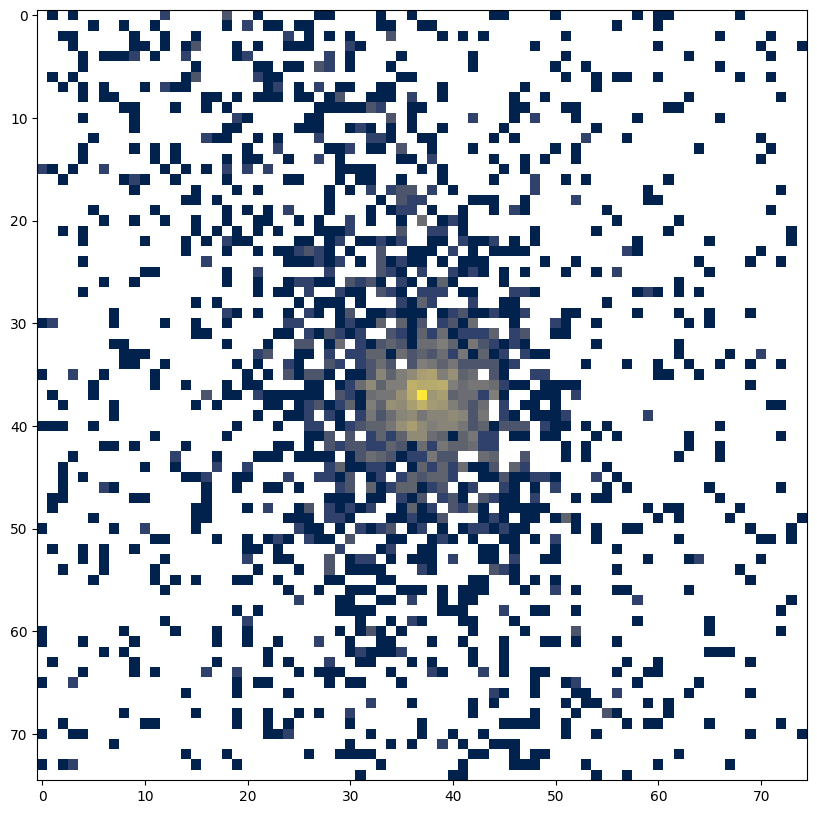

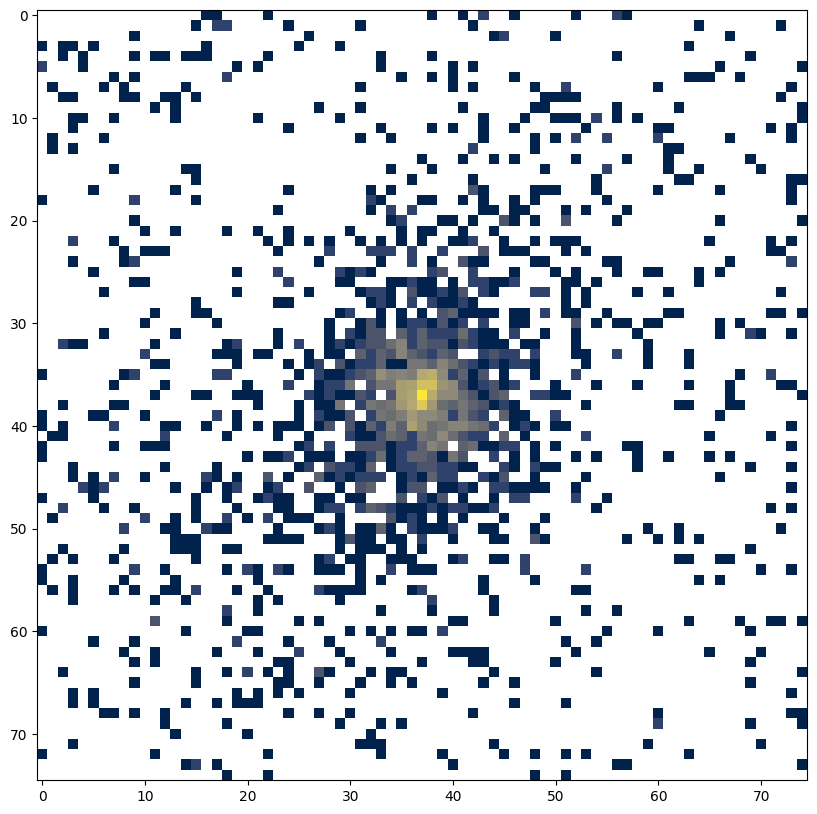

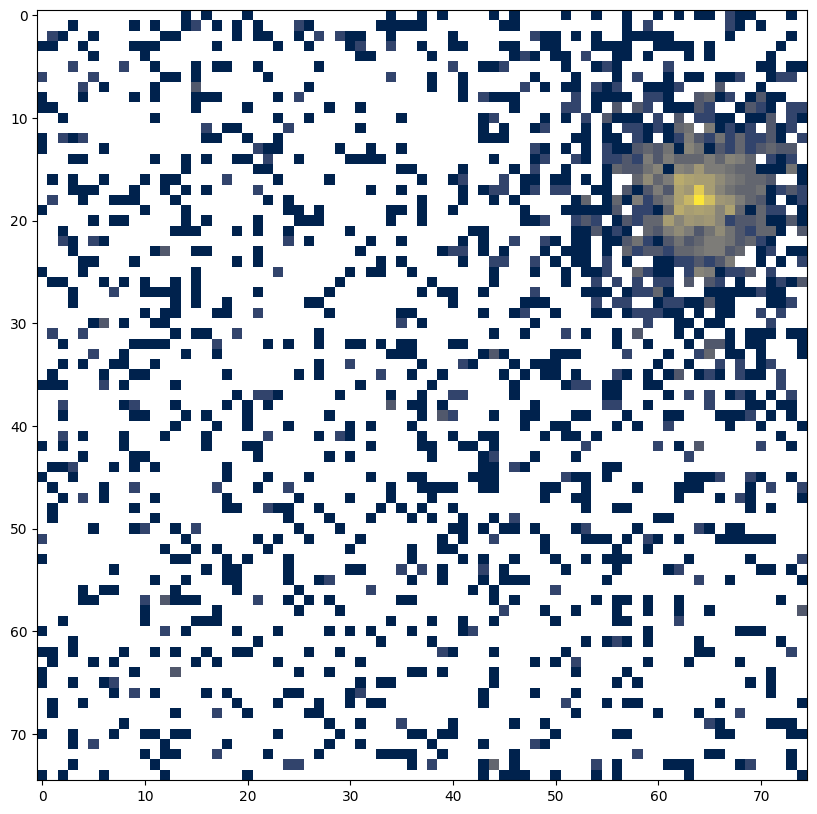

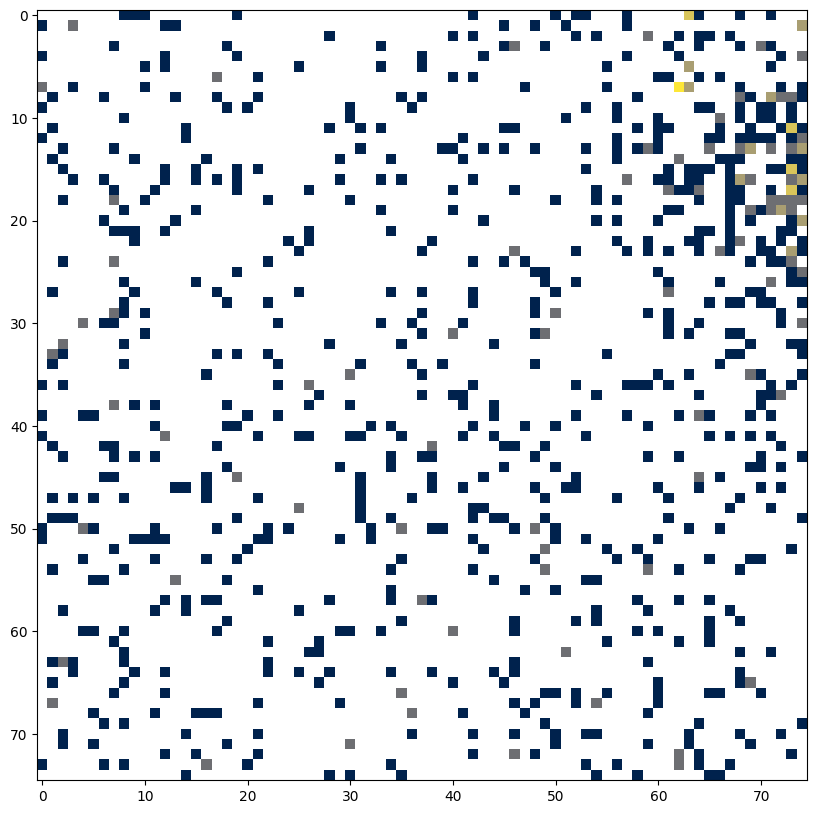

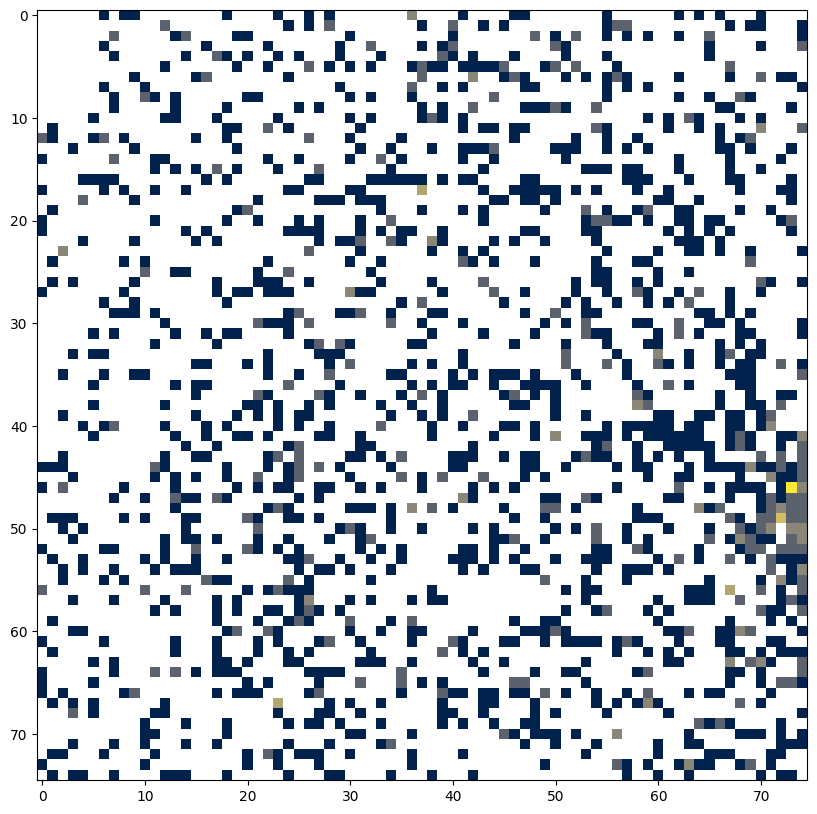

In [12]:
failed_snaps = [] # Sometimes the ellipse fitting fails, so store these snaps in this list
table_info = [] # Append rows of ellipse information to this list to create table from later on

# Looping through every 10 snapshots (tqdm to see progress)
for snap in tqdm(snap_range):
    # Create HaloShape object at given snap (see HaloShape.py)
    M33 = HaloShape('M33', snap)

    # See if ellipse fitting works for face-on projection of M33 
    try:
        # Retrieve fitting of all ellipses, and then the ellipticity, position angle, semimajor axis (a) in kpc, and semiminor axis (b)
        # in kpc at R500, R500/2, and R500/4
        isophotes, eps, pa, sma, smb = M33.PlotEllipses(0, 2) # (0 means x axis, 1 means y axis)

        # Save the snapshot time (Myr), and the ellipse information at R500, R500/2, and R500/4 to a row for our table
        row = M33.time.value, *tuple(eps), *tuple(pa), *tuple(sma), *tuple(smb)

        # Append row to table
        table_info.append(row)

    # If the ellipse fitting fails it will raise a ValueError
    except ValueError:
        # Try again but with smaller initial semimajor axis guess of 5 pixels (default is 10 pixels)
        try:
            isophotes, eps, pa, sma, smb = M33.PlotEllipses(0, 1, sma=5)
            row = M33.time.value, *tuple(eps), *tuple(pa), *tuple(sma), *tuple(smb)
            table_info.append(row)

        # If fails again, append snapshot to failed_snaps to see which snaps it failed at 
        except ValueError:  
            failed_snaps.append(snap)

In [33]:
failed_snaps

[220, 310, 320, 350, 410, 420, 440, 450, 470, 490, 500]

### Note: At each snapshot, the actual ellipses plotted on top of the projection are saved to the directory /plots/01/projections/. This is my other plot, which I will use later on to make a GIF. The radial profile of the fitted ellipses are similarly saved to /plots/01/ellipses/.

In [13]:
# Convert table information into a numpy array 
table_data = np.array(table_info)

# Save table to txt file 
np.savetxt('halo_evo_02.txt', table_data, fmt = "%11.3f"*13, comments='#',
               header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                      .format('t', 'r500_eps', 'r500/2_eps', 'r500/4_eps', 
                              'r500_pa', 'r500/2_pa', 'r500/4_pa',
                             'r500_sma', 'r500/2_sma', 'r500/4_sma',
                             'r500_smb', 'r500/2_smb', 'r500/4_smb'))

In [3]:
# Read in table information for the face-on projection (denoted 01)
Halo_01 = np.genfromtxt('halo_evo_01.txt')
Halo_12 = np.genfromtxt('halo_evo_12.txt')
Halo_02 = np.genfromtxt('halo_evo_02.txt')

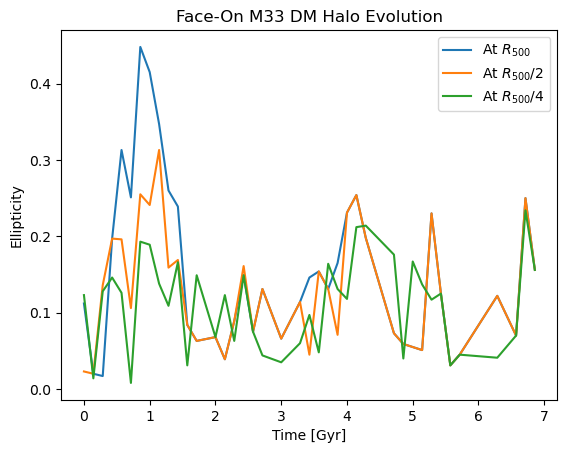

In [4]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
plt.plot(Halo_01[:,0]/1000, Halo_01[:,1], label=r'At $R_{500}$')
plt.plot(Halo_01[:,0]/1000, Halo_01[:,2], label=r'At $R_{500}/2$')
plt.plot(Halo_01[:,0]/1000, Halo_01[:,3], label=r'At $R_{500}/4$')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('Face-On M33 DM Halo Evolution')

plt.legend()

plt.savefig('Ellipticity_Evolution_01.png')

In [7]:
# 0 Time
# 1 , 2, 3: ellipticity r500, r500/2, r500/4
# 4, 5, 6: pa
# 7, 8, 9: a
# 10, 11, 12: b

In [14]:
Halo_12[:,10]

array([69.264, 68.911, 70.962, 68.675, 65.162, 60.397, 53.932, 55.857,
       56.797, 67.441, 56.764, 61.661, 62.409, 60.29 , 56.501, 55.783,
       55.005, 56.191, 56.248, 53.56 , 55.398, 55.407, 49.83 , 53.871,
       52.883, 50.438, 49.312, 48.997, 57.451, 55.036, 49.128, 48.871,
       46.75 , 42.664, 38.978, 45.22 , 45.645, 42.18 , 37.974, 34.434,
       34.494, 35.213, 33.087])

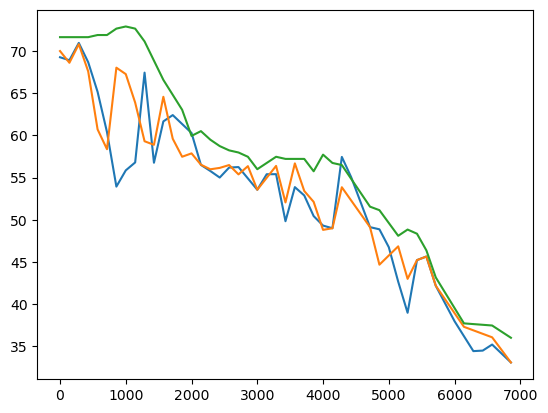

In [19]:
plt.plot(Halo_12[:,0], Halo_12[:,10])
plt.plot(Halo_02[:,0], Halo_02[:,10])
plt.plot(Halo_02[:,0], (Halo_02[:,7]))

In [44]:
mask_12 = np.isin(Halo_12[:,0], Halo_01[:,0])
mask_01 = np.isin(Halo_01[:,0], Halo_12[:,0])

In [34]:
time_mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True,  True])

In [35]:
Halo_12[:,0])

43

In [45]:
Halo_01[:,0][mask_01]

array([   0.   ,  142.857,  285.714,  428.571,  571.429,  714.286,
        857.143, 1000.   , 1142.857, 1285.714, 1428.571, 1571.429,
       1714.286, 2000.   , 2142.857, 2285.714, 2428.571, 2571.429,
       2714.286, 3000.   , 3285.714, 3428.571, 3571.429, 3714.286,
       3857.143, 4000.   , 4142.857, 4285.714, 4714.286, 4857.143,
       5000.   , 5142.857, 5285.714, 5428.571, 5571.429, 5714.286,
       6285.714, 6571.429, 6857.143])

In [43]:
Halo_12[:,0][mask_12]

array([   0.   ,  142.857,  285.714,  428.571,  571.429,  714.286,
        857.143, 1000.   , 1142.857, 1285.714, 1428.571, 1571.429,
       1714.286, 2000.   , 2142.857, 2285.714, 2428.571, 2571.429,
       2714.286, 3000.   , 3285.714, 3428.571, 3571.429, 3714.286,
       3857.143, 4000.   , 4142.857, 4285.714, 4714.286, 4857.143,
       5000.   , 5142.857, 5285.714, 5428.571, 5571.429, 5714.286,
       6285.714, 6571.429, 6857.143])

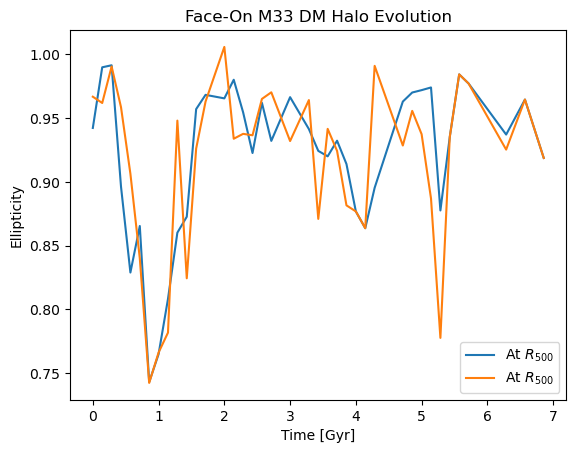

In [48]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
plt.plot(Halo_01[:,0][mask_01]/1000, Halo_01[:,10][mask_01]/Halo_01[:,7][mask_01], label=r'At $R_{500}$')
plt.plot(Halo_01[:,0][mask_01]/1000, Halo_12[:,10][mask_12]/Halo_01[:,7][mask_01], label=r'At $R_{500}$')
# plt.plot(Halo_02[:,0]/1000, Halo_02[:,1], label=r'At $R_{500}/2$')
# plt.plot(Halo_12[:,0]/1000, Halo_12[:,1], label=r'At $R_{500}/4$')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('Face-On M33 DM Halo Evolution')

plt.legend()

In [ ]:
def 

In [51]:
a = Halo_01[:,10][mask_01]
b = Halo_01[:,10][mask_01]
c = Halo_12[:,10][mask_12]

In [122]:
# def Triaxiality(proj1, proj2, r500_index):
#     # Read in table information for the face-on projection (denoted 01)
#     Halo_proj1 = np.genfromtxt(f'halo_evo_{proj1}.txt')
#     Halo_proj2 = np.genfromtxt(f'halo_evo_{proj2}.txt')
 
#     mask_proj1 = np.isin(Halo_proj1[:,0], Halo_proj2[:,0])
#     mask_proj2 = np.isin(Halo_proj2[:,0], Halo_proj1[:,0])
    
#     ar_proj1 = 1 - Halo_proj1[:, r500_index][mask_proj1]
#     ar_proj2 = 1 - Halo_proj2[:, r500_index][mask_proj2]
    
#     b_over_a = np.maximum(ar_proj1, ar_proj2)
#     c_over_a = np.minimum(ar_proj1, ar_proj2)
    
#     T = (1 - (b_over_a)**2)/(1 - (c_over_a)**2)
#     return Halo_proj1[:,0][mask_proj1]/1000, T

In [149]:
def Triaxiality(r500_index):
    # Read in table information for the face-on projection (denoted 01)
    Halo_01 = np.genfromtxt('halo_evo_01.txt')
    Halo_02 = np.genfromtxt('halo_evo_02.txt')
    Halo_12 = np.genfromtxt('halo_evo_12.txt')
 
    
    common = np.intersect1d(np.intersect1d(Halo_01[:,0], Halo_02[:,0]), Halo_12[:,0])
    
    mask_01 = np.isin(Halo_01[:,0], common)
    mask_02 = np.isin(Halo_02[:,0], common)
    mask_12 = np.isin(Halo_12[:,0], common)

    
    ar_01 = 1 - Halo_01[:, r500_index][mask_01]
    ar_02 = 1 - Halo_02[:, r500_index][mask_02]
    ar_12 = 1 - Halo_12[:, r500_index][mask_12]
    
    b_over_a = np.maximum(np.maximum(ar_01, ar_02), ar_12)
    c_over_a = np.minimum(np.minimum(ar_01, ar_02), ar_12)
    
    T = (1 - (b_over_a)**2)/(1 - (c_over_a)**2)
    return Halo_01[:,0][mask_01]/1000, T

In [147]:
Halo_01[:,0]

array([   0.   ,  142.857,  285.714,  428.571,  571.429,  714.286,
        857.143, 1000.   , 1142.857, 1285.714, 1428.571, 1571.429,
       1714.286, 2000.   , 2142.857, 2285.714, 2428.571, 2571.429,
       2714.286, 3000.   , 3285.714, 3428.571, 3571.429, 3714.286,
       3857.143, 4000.   , 4142.857, 4285.714, 4714.286, 4857.143,
       5000.   , 5142.857, 5285.714, 5428.571, 5571.429, 5714.286,
       6285.714, 6571.429, 6714.286, 6857.143])

In [148]:
import numpy as np

a = Halo_01[:,0]
b = Halo_12[:,0]
c = Halo_02[:,0]

# Step 1: Find values common to all three arrays
common = np.intersect1d(np.intersect1d(a, b), c)  # result: [3]

# Step 2: Crop each array to only include the common values
a_cropped = a[np.isin(a, common)]
b_cropped = b[np.isin(b, common)]
c_cropped = c[np.isin(c, common)]

print(a_cropped)  # [3]
print(b_cropped)  # [3]
print(c_cropped)  # [3]

[   0.     142.857  285.714  428.571  571.429  714.286  857.143 1000.
 1142.857 1285.714 1428.571 1571.429 1714.286 2000.    2142.857 2285.714
 2428.571 2571.429 2714.286 3000.    3285.714 3428.571 3571.429 3714.286
 3857.143 4000.    4142.857 4285.714 4714.286 4857.143 5142.857 5285.714
 5428.571 5571.429 5714.286 6571.429 6857.143]
[   0.     142.857  285.714  428.571  571.429  714.286  857.143 1000.
 1142.857 1285.714 1428.571 1571.429 1714.286 2000.    2142.857 2285.714
 2428.571 2571.429 2714.286 3000.    3285.714 3428.571 3571.429 3714.286
 3857.143 4000.    4142.857 4285.714 4714.286 4857.143 5142.857 5285.714
 5428.571 5571.429 5714.286 6571.429 6857.143]
[   0.     142.857  285.714  428.571  571.429  714.286  857.143 1000.
 1142.857 1285.714 1428.571 1571.429 1714.286 2000.    2142.857 2285.714
 2428.571 2571.429 2714.286 3000.    3285.714 3428.571 3571.429 3714.286
 3857.143 4000.    4142.857 4285.714 4714.286 4857.143 5142.857 5285.714
 5428.571 5571.429 5714.286 6571.429 68

In [139]:
np.maximum(np.maximum(np.arange(0,10), np.arange(50,60)), np.arange(40, 50))

array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59])

In [150]:
time, T1 = Triaxiality(1)

In [106]:
time2, T2 = Triaxiality('01', '02', 1)

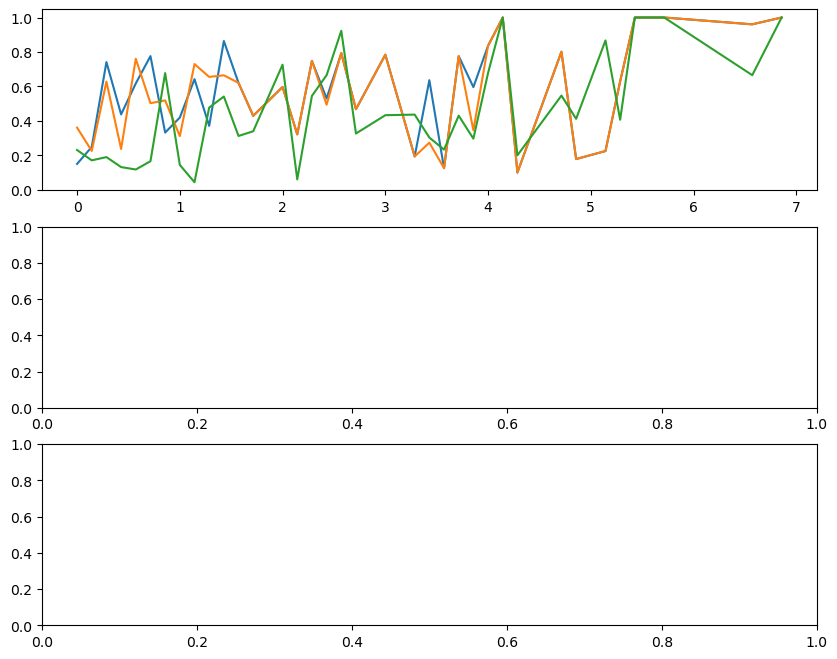

In [152]:
fig, ax = plt.subplots(3, figsize=(10,8))

T_R500 = Triaxiality(1)
T_R500d2 = Triaxiality(2)
T_R500d4 = Triaxiality(3)

# T_R500_12 = Triaxiality('01', '12', 1)
# T_R500d2_12 = Triaxiality('01', '12', 2)
# T_R500d4_12 = Triaxiality('01', '12', 3)

# T_R500_02 = Triaxiality('01', '02', 1)
# T_R500d2_02 = Triaxiality('01', '02', 2)
# T_R500d4_02 = Triaxiality('01', '02', 3)

# T_R500_01 = Triaxiality('02', '12', 1)
# T_R500d2_01 = Triaxiality('02', '12', 2)
# T_R500d4_01 = Triaxiality('02', '12', 3)


ax[0].plot(T_R500_12[0], T_R500_12[1])
ax[0].plot(T_R500d2_12[0], T_R500d2_12[1])
ax[0].plot(T_R500d4_12[0], T_R500d4_12[1])

# ax[0].plot(T_R500_02[0], T_R500_02[1])
# ax[1].plot(T_R500d2_02[0], T_R500d2_02[1])
# ax[2].plot(T_R500d4_02[0], T_R500d4_02[1])

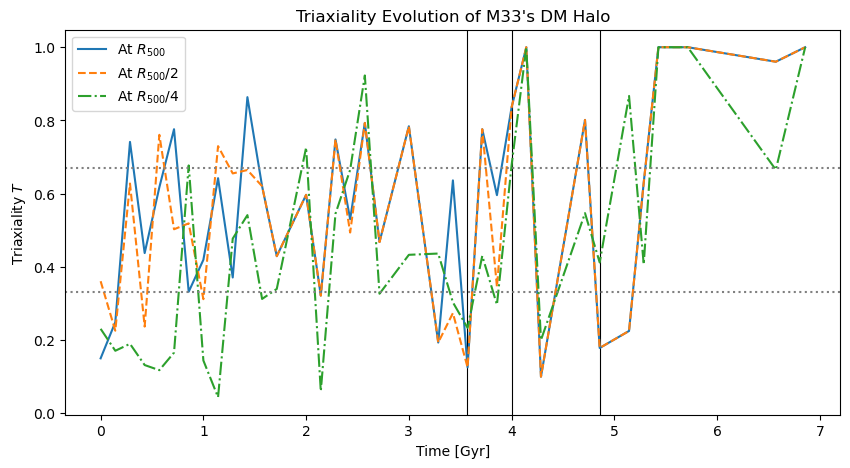

In [278]:
plt.figure(figsize=(10,5))

plt.axvline(3.57, c='k', linestyle='-', linewidth=0.8)
plt.axvline(4.0, c='k', linestyle='-', linewidth=0.8)
plt.axvline(4.86, c='k', linestyle='-', linewidth=0.8)

plt.plot(T_R500[0], T_R500[1], label=r'At $R_{500}$')
plt.plot(T_R500d2[0], T_R500d2[1], linestyle='--', label=r'At $R_{500}/2$')
plt.plot(T_R500d4[0], T_R500d4[1], linestyle='-.', label=r'At $R_{500}/4$')

plt.axhline(0.33, c='gray', linestyle=':')
plt.axhline(0.67, c='gray', linestyle=':')

plt.legend()

plt.ylabel('Triaxiality $T$')
plt.xlabel('Time [Gyr]')

plt.title("Triaxiality Evolution of M33's DM Halo")

plt.savefig('Triaxiality_Evo.png', bbox_inches='tight')

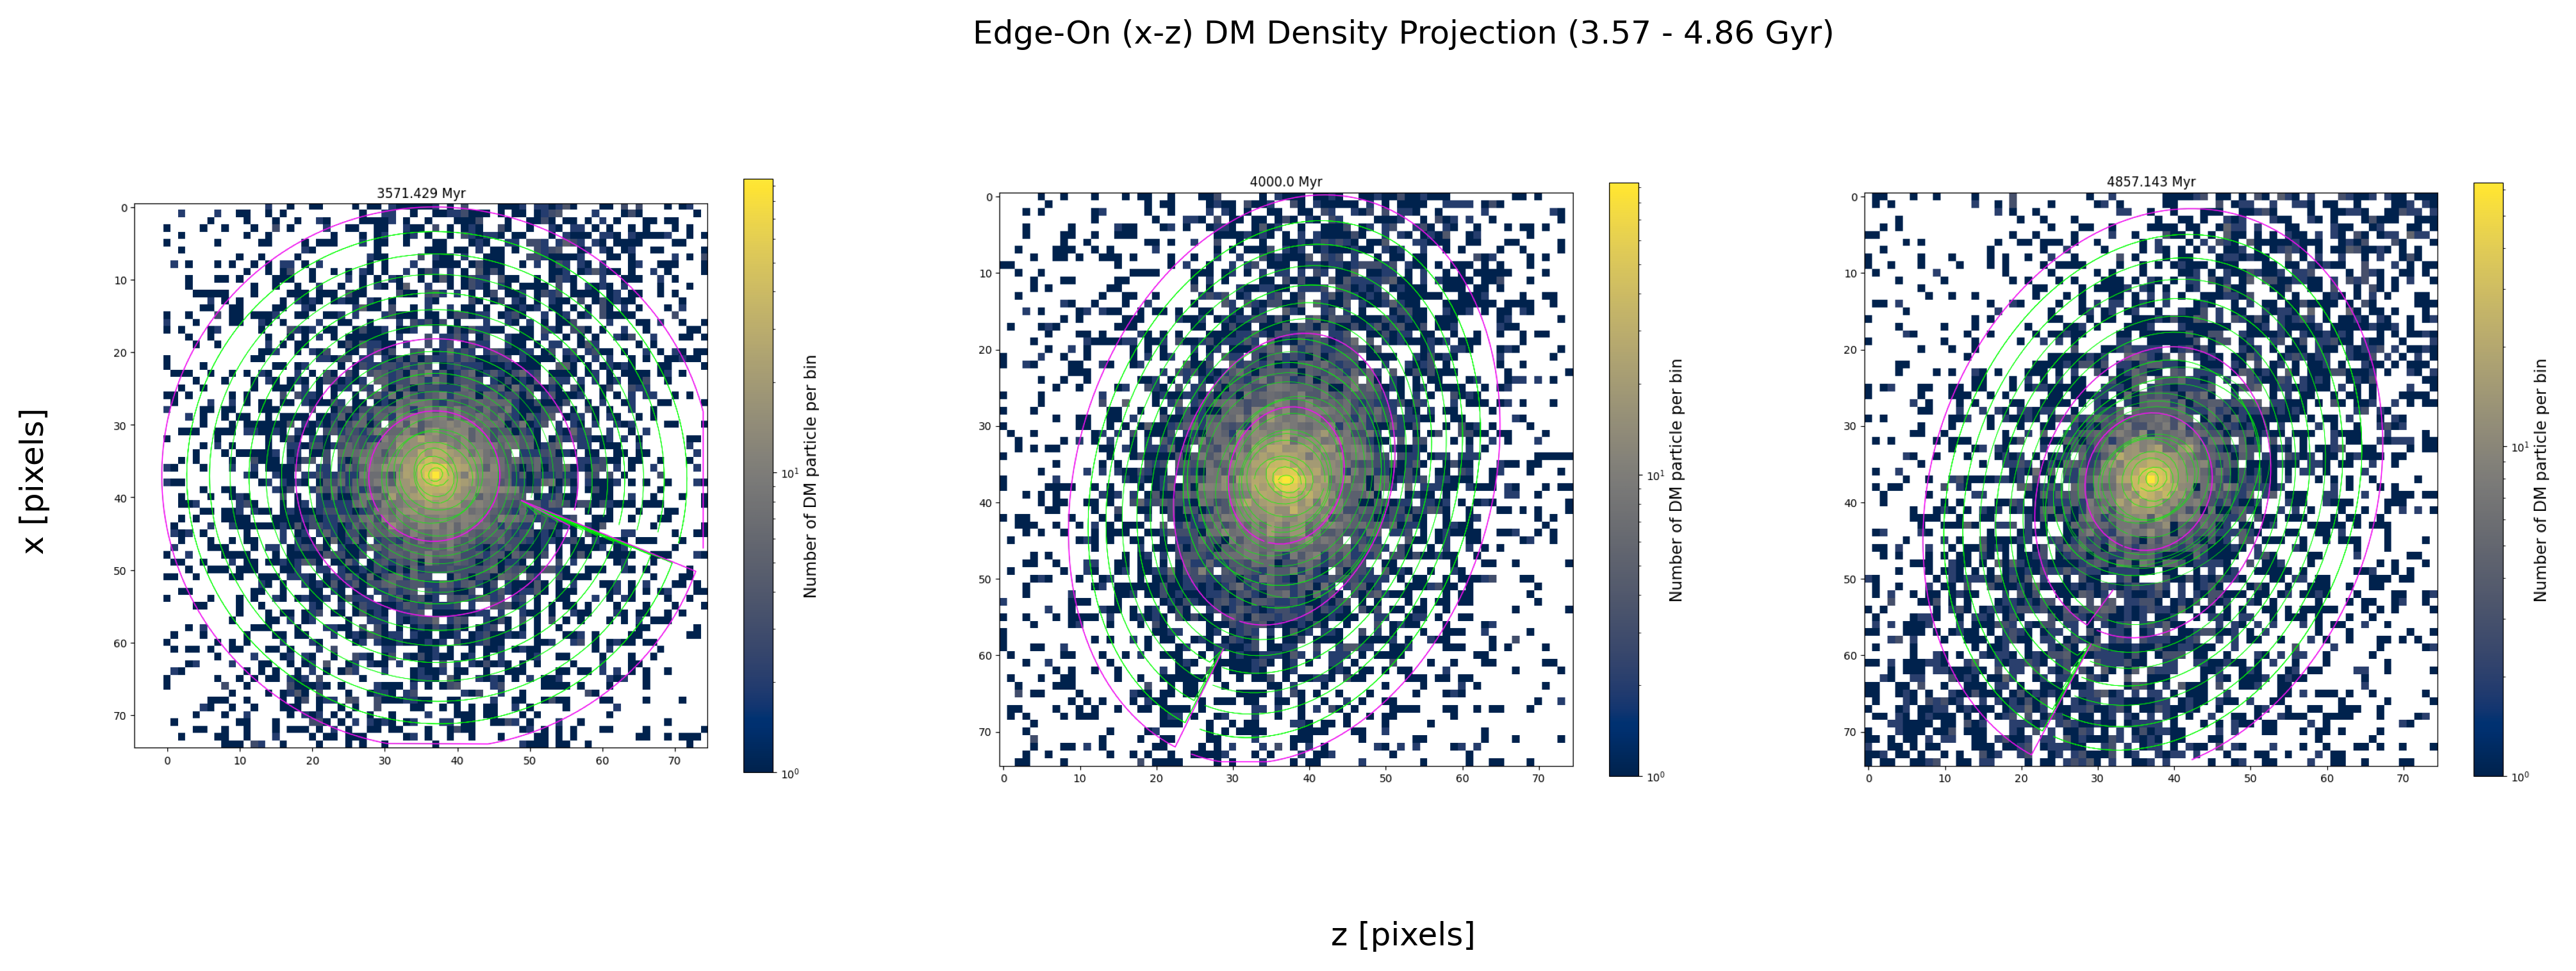

In [280]:
import matplotlib.image as mpimg


snap_280 = mpimg.imread('../ResearchAssignment5/plots/02/projections/M33_280.png')
snap_250 = mpimg.imread('../ResearchAssignment5/plots/02/projections/M33_250.png')
snap_340 = mpimg.imread('../ResearchAssignment5/plots/02/projections/M33_340.png')

fig, ax = plt.subplots(1, 3, figsize=(15,5), dpi=300)

ax[0].imshow(snap_250)
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

for spine in ax[0].spines.values():
    spine.set_visible(False)
    
ax[1].imshow(snap_280)
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

for spine in ax[1].spines.values():
    spine.set_visible(False)
    
ax[2].imshow(snap_340)
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

for spine in ax[2].spines.values():
    spine.set_visible(False)
    
fig.supxlabel('z [pixels]')
fig.supylabel('x [pixels]' )
fig.subplots_adjust(left=0.05, bottom=0.001, top=1)

fig.suptitle('Edge-On (x-z) DM Density Projection (3.57 - 4.86 Gyr)')

fig.savefig('XZ_Evo_NearMerger.pdf', bbox_inches='tight')

In [116]:
Triaxiality('01', '12', 1)

(array([   0.   ,  142.857,  285.714,  428.571,  571.429,  714.286,
         857.143, 1000.   , 1142.857, 1285.714, 1428.571, 1571.429,
        1714.286, 2000.   , 2142.857, 2285.714, 2428.571, 2571.429,
        2714.286, 3000.   , 3285.714, 3428.571, 3571.429, 3714.286,
        3857.143, 4000.   , 4142.857, 4285.714, 4714.286, 4857.143,
        5000.   , 5142.857, 5285.714, 5428.571, 5571.429, 5714.286,
        6285.714, 6571.429, 6857.143]),
 array([0.15012107, 0.27428571, 0.89564016, 0.43762089, 0.61731035,
        0.87526019, 0.95441366, 0.99643647, 0.91528677, 0.42395889,
        0.8636179 , 0.87189516, 0.86749223, 0.59676044, 0.48627254,
        0.74806364, 0.53018321, 0.92286753, 0.46773186, 0.78417447,
        0.19329408, 0.63625081, 0.4490017 , 0.77602016, 0.76406045,
        1.        , 1.        , 0.09998991, 0.80137977, 0.65103607,
        0.47051139, 0.22488919, 0.64213889, 1.        , 1.        ,
        1.        , 0.85726473, 1.        , 1.        ]))

In [109]:
T2

array([0.416044  , 0.24888286, 0.74137362, 0.58531888, 0.93106465,
       0.77600187, 0.33204707, 0.41929079, 0.70166896, 0.87509067,
       0.90387403, 0.71154563, 0.42925736, 1.        , 0.3215146 ,
       0.7910504 , 0.59682595, 0.79320519, 0.6797569 , 0.78417447,
       0.33781232, 0.86091039, 0.12549422, 0.97866761, 0.77986624,
       0.83604726, 1.        , 0.48688606, 0.80137977, 0.27407971,
       1.        , 0.98102432, 1.        , 1.        , 1.        ,
       0.96039695, 1.        ])

In [86]:
ar_01 = 1 - Halo_01[:,1][mask_01]
ar_12 = 1 - Halo_12[:,1][mask_12]

In [89]:
b_over_a = np.maximum(ar_01, ar_12)
c_over_a = np.minimum(ar_01, ar_12)

array([0.888, 0.925, 0.981, 0.803, 0.687, 0.706, 0.552, 0.585, 0.611,
       0.74 , 0.716, 0.903, 0.927, 0.932, 0.918, 0.879, 0.851, 0.925,
       0.869, 0.915, 0.886, 0.758, 0.846, 0.869, 0.777, 0.769, 0.746,
       0.802, 0.908, 0.941, 0.879, 0.747, 0.605, 0.875, 0.969, 0.955,
       0.856, 0.93 , 0.844])

In [80]:
b_over_a > c_over_a

array([False,  True,  True, False, False,  True, False, False,  True,
       False,  True,  True,  True, False,  True,  True, False, False,
       False,  True, False,  True, False, False,  True, False, False,
       False,  True, False,  True,  True,  True, False, False, False,
        True, False, False])

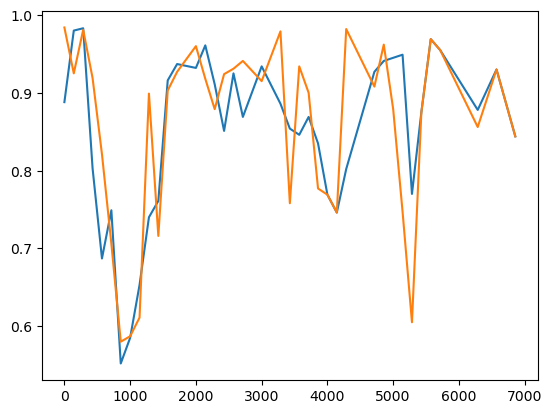

In [82]:
plt.plot(Halo_01[:,0][mask_01], b_over_a)
plt.plot(Halo_01[:,0][mask_01], c_over_a)

In [91]:
T = (1 - (b_over_a)**2)/(1 - (c_over_a)**2)

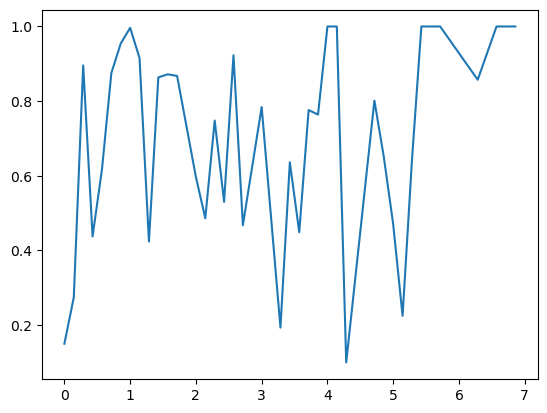

In [92]:
plt.plot(Halo_01[:,0][mask_01]/1000, T)

In [55]:
T = (a**2 - b**2)/(a**2 - c**2)

/var/folders/dw/_w8f0l7d4w5_st5k1hsv1z9c0000gn/T/ipykernel_38920/3383157679.py:1: RuntimeWarning: invalid value encountered in divide
  T = (a**2 - b**2)/(a**2 - c**2)


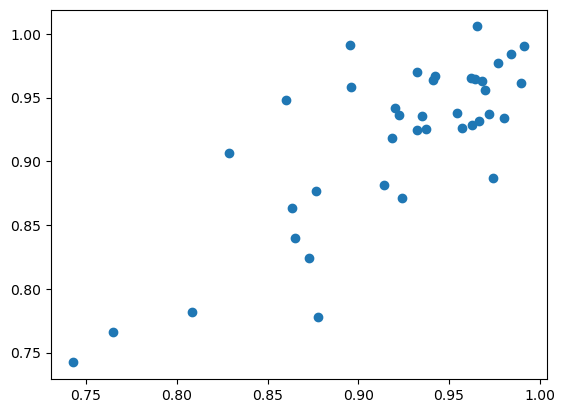

In [49]:
plt.scatter(Halo_01[:,10][mask_01]/Halo_01[:,7][mask_01], Halo_12[:,10][mask_12]/Halo_01[:,7][mask_01], label=r'At $R_{500}$')

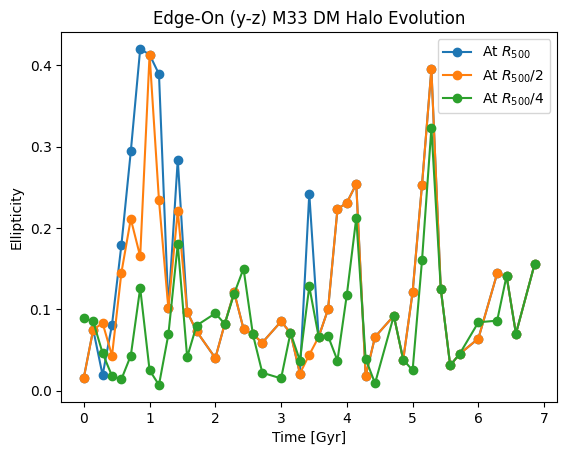

In [11]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
plt.plot(Halo_12[:,0]/1000, Halo_12[:,1], label=r'At $R_{500}$', marker='o')
plt.plot(Halo_12[:,0]/1000, Halo_12[:,2], label=r'At $R_{500}/2$', marker='o')
plt.plot(Halo_12[:,0]/1000, Halo_12[:,3], label=r'At $R_{500}/4$', marker='o')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('Edge-On (y-z) M33 DM Halo Evolution')

plt.legend()

plt.savefig('Ellipticity_Evolution_12.png')

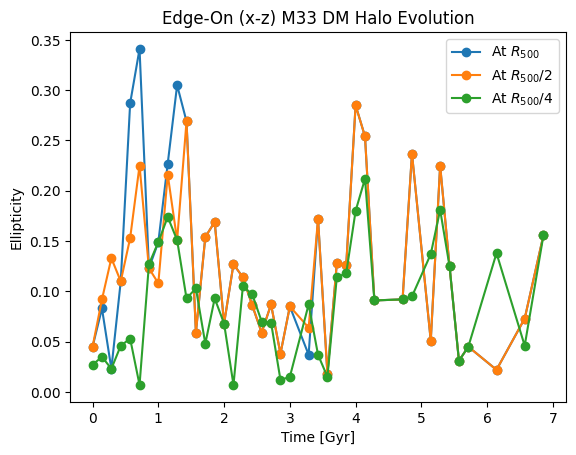

In [16]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
plt.plot(Halo_02[:,0]/1000, Halo_02[:,1], label=r'At $R_{500}$', marker='o')
plt.plot(Halo_02[:,0]/1000, Halo_02[:,2], label=r'At $R_{500}/2$', marker='o')
plt.plot(Halo_02[:,0]/1000, Halo_02[:,3], label=r'At $R_{500}/4$', marker='o')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('Edge-On (x-z) M33 DM Halo Evolution')

plt.legend()

plt.savefig('Ellipticity_Evolution_02.png')

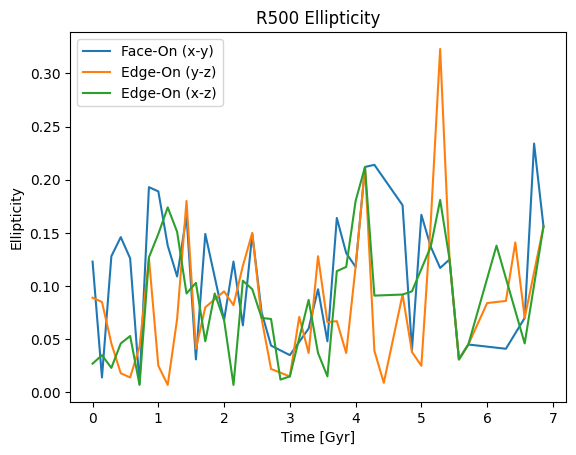

In [32]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
j = 3

plt.plot(Halo_01[:,0]/1000, Halo_01[:,j], label=r'Face-On (x-y)')
plt.plot(Halo_12[:,0]/1000, Halo_12[:,j], label=r'Edge-On (y-z)')
plt.plot(Halo_02[:,0]/1000, Halo_02[:,j], label=r'Edge-On (x-z)')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('R500 Ellipticity')

plt.legend()

#plt.savefig('Ellipticity_Evolution_02.png')

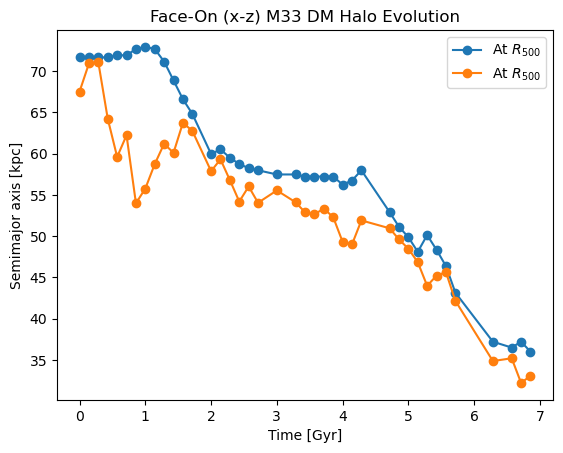

In [5]:
plt.plot(Halo_01[:,0]/1000, Halo_01[:,7], label=r'At $R_{500}$', marker='o')
plt.plot(Halo_01[:,0]/1000, Halo_01[:,10], label=r'At $R_{500}$', marker='o')
# plt.plot(Halo_02[:,0]/1000, Halo_02[:,9], label=r'At $R_{500}$', marker='o')
# plt.plot(Halo_12[:,0]/1000, Halo_12[:,9], label=r'At $R_{500}$', marker='o')

#plt.plot(Halo_02[:,0]/1000, Halo_02[:,2], label=r'At $R_{500}/2$', marker='o')
#plt.plot(Halo_02[:,0]/1000, Halo_02[:,3], label=r'At $R_{500}/4$', marker='o')

plt.xlabel('Time [Gyr]')
plt.ylabel('Semimajor axis [kpc]')

plt.title('Face-On (x-z) M33 DM Halo Evolution')

plt.legend()

#plt.savefig('Ellipticity_Evolution_02.png')